# Predicting MLB Free Agent Contracts with Machine Learning
### A Step-by-Step Explanatory Guide

---

**Authors:** Siddika Bhuiyanmishu, Sai Rakshit Goud Pudari, Cliff Saul, & Michael Wellen

**Dataset:** FanGraphs player statistics (2016–2025) × MLB free agent contracts (2017–2026)  

**Test set:** 54 contracts signed after the 2025 season (Starting Year 2026)

---

## What this notebook does

Every winter, major league teams must decide how much money to offer free agents — players who are no longer under contract and free to negotiate with anyone. Getting these decisions wrong is expensive: a bad $100M contract can cripple a franchise's payroll for years.

This notebook walks through a machine learning pipeline that predicts two things for each free agent:

1. **Average Annual Value (AAV):** How much per year should this player earn?
2. **Contract Length:** How many years should the deal be?

We build, test, and compare multiple models, and end with a **deployed hybrid system** that selects the best model depending on how good the player is.

---

## Table of Contents
1. The Data
2. Step 1 — Deciding Who Gets a Major League Contract (Phase 1 Classifier)
3. Step 2 — Feature Engineering: Turning Statistics into Model Inputs
4. Step 3 — The WAR Aging Curve: Projecting Future Performance
5. Step 4 — Positional Scarcity: Why Position Matters for Salary
6. Step 5 — Player Clustering: Finding Archetypes
7. Step 6 — The Comparable Contract Engine
8. Step 7 — Model Selection: Choosing the Right Algorithm per Tier
9. Step 8 — The Deployed Hybrid Model
10. Results: What the Numbers Tell Us
11. Limitations and Future Work


---
## Section 1: The Data

Before building any model, we need to understand what data we have. This pipeline uses two datasets:

### Dataset 1: MLB Free Agent Contracts (2017–2026)
Each row is one free agent signing. The key fields are:
- **name / pos:** Player name and defensive position
- **Contract Year:** The season the player played before signing (used to join to stats)
- **Starting Year:** The first year of the new contract (used for salary floor enforcement)
- **aav:** Average Annual Value — total contract value divided by years
- **yrs:** Contract length in years
- **mlb_contract:** 1 if this is a guaranteed major league contract, 0 if a minor league deal

### Dataset 2: FanGraphs Player Statistics (2016–2025)
Each row is one player-season. The key statistics include:
- **WAR** (Wins Above Replacement): the most important single number — how many wins did this player contribute compared to a freely available replacement player? A 0 WAR player is replacement level; 2 WAR is a solid regular; 5+ WAR is All-Star calibre.
- **wRC+** (Weighted Runs Created Plus): offensive production, park-adjusted. 100 = league average.
- **xwOBA** (Expected Weighted On-Base Average): contact quality, stripped of luck
- **Def / BsR:** Defensive and baserunning value
- **Barrel% / HardHit%:** Batted ball quality (Statcast era metrics)

### Why it matters that we exclude Shohei Ohtani
Ohtani is removed from all analyses. He simultaneously plays as an elite pitcher and an elite hitter — a combination that makes his WAR incomparable to every other player. Including him would confuse every model.


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
# All the tools we'll need throughout this notebook.
import pandas as pd
import numpy as np
import warnings
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, r2_score
)
from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
    print(f"XGBoost {__import__('xgboost').__version__} available — will be used as a candidate model")
except ImportError:
    HAS_XGB = False
    print("[INFO] XGBoost not installed. GBM is used as a substitute.")

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
CLR = {
    'bg':'#0d1117','panel':'#161b22','accent1':'#58a6ff','accent2':'#3fb950',
    'accent3':'#f78166','accent4':'#d2a8ff','accent5':'#ffa657','text':'#e6edf3',
    'muted':'#8b949e','grid':'#21262d','green2':'#39d353',
}
TIER_COLORS = {'fringe':'#8b949e','role':'#58a6ff','upper':'#ffa657'}
ALGO_COLORS = {'GBM':'#58a6ff','RF':'#3fb950','XGB':'#ffa657','Ridge':'#8b949e'}

plt.rcParams.update({
    'figure.facecolor':CLR['bg'],'axes.facecolor':CLR['panel'],
    'text.color':CLR['text'],'axes.labelcolor':CLR['text'],
    'xtick.color':CLR['text'],'ytick.color':CLR['text'],
    'axes.edgecolor':CLR['grid'],'grid.color':CLR['grid'],
    'font.family':'DejaVu Sans',
})

def ax_style(ax, title, xlabel='', ylabel='', fontsize=12):
    ax.set_facecolor(CLR['panel'])
    ax.set_title(title, color=CLR['text'], fontsize=fontsize, fontweight='bold', pad=10)
    if xlabel: ax.set_xlabel(xlabel, color=CLR['muted'], fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=CLR['muted'], fontsize=9)
    ax.grid(True, alpha=0.3, color=CLR['grid'])
    for sp in ax.spines.values(): sp.set_edgecolor(CLR['grid'])

print("Setup complete.")


XGBoost 3.2.0 available — will be used as a candidate model
Setup complete.


### Loading the Data

We load both datasets and remove Ohtani. We also construct the **league AAV index** — a year-by-year measure of how much the free agent market has grown. This is critical for making historical comparable contracts ("comps") comparable to today's dollars.

The index is anchored to 2019 (= 1.0), the last pre-COVID normal season. A 2018 contract worth \$10M in a 0.93× market is worth \$10M × (1.44/0.93) ≈ $15.5M in 2025 dollars.


In [2]:
import pandas as pd
import numpy as np
import warnings
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, r2_score, mean_squared_error
)
from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
    print("XGBoost:", __import__('xgboost').__version__)
except ImportError:
    HAS_XGB = False
    print("[INFO] XGBoost not available — GBM used as substitute.")

warnings.filterwarnings('ignore')

# ── CONSTANTS ─────────────────────────────────────────────────────────────────

STAT_COLS = [
    'WAR', 'wRC+', 'wOBA', 'OBP', 'SLG', 'ISO', 'BABIP',
    'BB%', 'K%', 'HR', 'SB', 'Def', 'BsR', 'Off',
    'Barrel%', 'HardHit%', 'xwOBA', 'xSLG', 'PA', 'G',
    'wRAA', 'OBP+', 'ISO+', 'WPA', 'Clutch', 'Spd', 'Age'
]

TEAM_INTEREST_COLS = [
    'n_teams_interested', 'n_rumor_mentions',
    'has_big_market_interest', 'first_rumor_doy', 'rumor_intensity',
]

MLB_MINIMUM_SALARY = {
    2016:507_500,  # CBA minimum before 2017 increase
    2017:535_000, 2018:545_000, 2019:555_000, 2020:563_500,
    2021:570_500, 2022:700_000, 2023:720_000, 2024:740_000,
    2025:760_000, 2026:780_000,
}

def apply_salary_floor(aav: float, starting_year: int) -> float:
    min_sal = MLB_MINIMUM_SALARY.get(
        int(starting_year), MLB_MINIMUM_SALARY[max(MLB_MINIMUM_SALARY)]
    )
    return max(float(aav), float(min_sal))

def round_years(yrs_float: float) -> int:
    return max(1, int(round(float(yrs_float))))

# ── POSITION SEGMENTS (4-group, unchanged from v9) ────────────────────────────
POS_SEGMENT_MAP = {
    'OF': ['LF','CF','RF','LF/CF','LF/RF','RF/LF','LF/OF','RF/RF','CF/1B',
           'LF/DH','DH/OF','DH/LF','DH/RF','LF/1B','RF/2B','RF/3B'],
    'BAT':['1B','DH','1B/DH','DH/1B','1B/RF','1B/OF','1B/3B','DH/1B/RF','SP/DH'],
    'INF':['2B','3B','SS','SS/SS','SS/2B','SS/CF','SS/3B','SS/OF',
           '2B/SS','2B/3B','3B/1B','3B/SS','3B/2B','3B/SS/OF',
           '2B/RF/DH','2B/LF','RF/3B'],
    'C':  ['C','C/C','C/DH','C/1B'],
}
INF_SUB_MAP = {
    'SS':['SS','SS/SS','SS/2B','SS/CF','SS/3B','SS/OF'],
    '3B':['3B','3B/1B','3B/SS','3B/2B','3B/SS/OF','RF/3B'],
    '2B':['2B','2B/SS','2B/3B','2B/RF/DH','2B/LF'],
}
INF_SUB_ENCODE = {'SS':2,'3B':1,'2B':0}

def get_segment(pos):
    if not isinstance(pos, str): return 'OTHER'
    for seg, variants in POS_SEGMENT_MAP.items():
        if pos in variants: return seg
    return 'OTHER'

def get_inf_sub_encoded(pos):
    if not isinstance(pos, str): return -1
    for sub, variants in INF_SUB_MAP.items():
        if pos in variants: return INF_SUB_ENCODE[sub]
    return -1

COMP_FEATURES = [
    'mean_WAR','mean_xwOBA','mean_Barrel%','mean_HardHit%',
    'mean_OBP','mean_ISO','mean_Def','mean_BsR','mean_Age',
]
COMP_WEIGHTS = {
    'mean_WAR':3.0,'mean_xwOBA':2.0,'mean_Barrel%':1.0,'mean_HardHit%':1.0,
    'mean_OBP':1.0,'mean_ISO':1.0,'mean_Def':1.5,'mean_BsR':0.5,'mean_Age':2.0,
}
MAX_PROJ_YEARS   = 5
PA_HEALTHY_FLOOR = 350
UPPER_WAR_FLOOR  = 2.0

XGBoost: 3.2.0


In [3]:
contracts = pd.read_csv('/content/mlb_contracts_9.csv')
players   = pd.read_csv('/content/mlb_player.csv')

contracts = contracts[~contracts['name'].str.contains('Ohtani', na=False)].copy()
players   = players[~players['Name'].str.contains('Ohtani', na=False)].copy()
contracts = contracts[contracts['mlbam_id'].notna()].copy()
contracts['mlbam_id'] = contracts['mlbam_id'].astype(int)

for col in TEAM_INTEREST_COLS:
    contracts[col] = 365 if col == 'first_rumor_doy' else 0

mlb_aav_by_year = (
    contracts[contracts['mlb_contract'] == 1]
    .groupby('Contract Year')['aav'].median()
    .rename('league_median_aav')
)
BASE_YEAR = 2019
base_aav  = mlb_aav_by_year.get(BASE_YEAR, mlb_aav_by_year.mean())
aav_index = (mlb_aav_by_year / base_aav).rename('aav_market_index')

MARKET_TABLE = {
    2016:(9.0,189.0), 2017:(9.5,195.0), 2018:(10.3,197.0),
    2019:(10.7,206.0), 2020:(3.6,208.0), 2021:(9.0,210.0),
    2022:(10.8,230.0), 2023:(11.4,233.0), 2024:(11.9,237.0),
    2025:(12.5,241.0),
}

print(f"Contracts : {len(contracts):,}   Player-seasons: {len(players):,}")
print(f"AAV index : {dict(aav_index.round(3))}")


Contracts : 2,288   Player-seasons: 5,129
AAV index : {2016: np.float64(1.375), 2017: np.float64(1.0), 2018: np.float64(0.938), 2019: np.float64(1.0), 2020: np.float64(0.75), 2021: np.float64(1.25), 2022: np.float64(1.562), 2023: np.float64(0.75), 2024: np.float64(1.0), 2025: np.float64(1.5)}


In [4]:
# ── Quick look at the data ────────────────────────────────────────────────────
print(f"Total contracts: {len(contracts):,}")
print(f"MLB contracts  : {(contracts['mlb_contract']==1).sum():,}")
print(f"Minor contracts: {(contracts['mlb_contract']==0).sum():,}")
print(f"Contract years : {contracts['Contract Year'].min()} – {contracts['Contract Year'].max()}")
print()
print("MLB contracts by year:")
print(contracts[contracts['mlb_contract']==1]['Contract Year'].value_counts().sort_index().to_string())
print()
print("\nLeague AAV market index (2019 = 1.0):")
for yr, val in aav_index.items():
    print(f"  {yr}: {val:.3f}")


Total contracts: 2,288
MLB contracts  : 574
Minor contracts: 1,714
Contract years : 2016 – 2025

MLB contracts by year:
Contract Year
2016    50
2017    38
2018    48
2019    61
2020    63
2021    61
2022    70
2023    55
2024    71
2025    57


League AAV market index (2019 = 1.0):
  2016: 1.375
  2017: 1.000
  2018: 0.938
  2019: 1.000
  2020: 0.750
  2021: 1.250
  2022: 1.562
  2023: 0.750
  2024: 1.000
  2025: 1.500


**Reading the market index:** The 2020 value near 0.7 reflects the COVID-shortened season, which depressed revenue and the resulting free agent market significantly. By 2025 the index is around 1.44 — meaning the market has grown 44% since 2019. Any comp contract signed in 2018 needs to be scaled up by roughly 55% to be comparable to a 2025 deal.


---
## Section 2: Step 1 — Deciding Who Gets a Major League Contract

Not every free agent receives a guaranteed major league contract. Many players receive **minor league contracts** — deals with no guaranteed salary, only an invitation to spring training. These contracts have completely different dynamics from major league deals.

**Why separate this into its own step?**  
If we tried to predict AAV for everyone, minor league contracts (AAV = $0 to a few hundred thousand) would dominate the dataset and distort every model. We solve this by training a **classifier** first — a model that simply asks: *"Is this player going to get a major league contract?"*

### What is a Gradient Boosting Classifier?

A classifier is an algorithm that sorts things into categories. Think of it as a very sophisticated decision tree — the model learns rules like:
- "If WAR > 1.5 AND age < 35 AND PA > 400, predict MLB contract"
- "If WAR < 0, predict minor league"

**Gradient Boosting** builds these rules sequentially: each new rule corrects the mistakes of all the previous rules. After 300 rounds of correction, the model is very good at finding the boundary between MLB and minor league quality.

**How do we evaluate a classifier?**  
The key metric is **ROC-AUC** (Area Under the Receiver Operating Characteristic curve). It ranges from 0.5 (random guessing) to 1.0 (perfect). An AUC above 0.90 is considered excellent.

We also use **5-fold cross-validation**: the data is split into 5 chunks, and the model is tested on each chunk while trained on the other four. This gives us 5 independent test scores, which we average for a reliable estimate of real-world performance.


In [5]:
import pandas as pd
import numpy as np

# TEAM_INTEREST_COLS and STAT_COLS are defined in the imports cell above.

TEAM_INTEREST_CACHE = '/content/team_interest_cache.csv'

try:
    ti_df = pd.read_csv(TEAM_INTEREST_CACHE)
    ti_df['mlbam_id']      = ti_df['mlbam_id'].astype(int)
    ti_df['contract_year'] = ti_df['contract_year'].astype(int)

    # Perform the merge, pandas will add suffixes (_x for left, _y for right)
    # We explicitly define suffixes to be sure, though pandas does this by default on conflict.
    merged_contracts = contracts.merge(
        ti_df[['mlbam_id', 'contract_year'] + TEAM_INTEREST_COLS],
        left_on  = ['mlbam_id', 'Contract Year'],
        right_on = ['mlbam_id', 'contract_year'],
        how='left',
        suffixes=('_x', '_y')
    )

    # Count how many entries were successfully merged (i.e., ti_df had data)
    # We check the first TEAM_INTEREST_COLS column with the _y suffix for non-nulls.
    n_matched = merged_contracts[TEAM_INTEREST_COLS[0] + '_y'].notna().sum()

    # Update the original TEAM_INTEREST_COLS in `contracts` (which corresponds to `_x` columns in `merged_contracts`)
    # with the values from `_y` columns, falling back to `_x` if `_y` is NaN.
    for col in TEAM_INTEREST_COLS:
        contracts[col] = merged_contracts[f'{col}_y'].fillna(merged_contracts[f'{col}_x'])

    print(f"  Team-interest cache loaded: {n_matched:,} / {len(contracts):,} rows matched")

    # Clean up the temporary _x and _y columns if they are not explicitly dropped by reassigning `contracts`
    # The previous loop has already updated `contracts` in place, so we need to drop the _x and _y columns
    # that are still lingering in `merged_contracts` if we want to be clean.
    # However, since `contracts` is updated in the loop directly, `merged_contracts` is no longer needed.
    # The previous `contracts` variable already contains the default values, so filling `_y` with `_x` is correct.

    HAS_TEAM_INTEREST = True

except FileNotFoundError:
    print(
        f"  [INFO] Team-interest cache not found at '{TEAM_INTEREST_CACHE}'.\n"
        "         Run mlb_scraper_ner.py to generate it.\n"
        "         Proceeding with neutral defaults (0 / 365)"
    )
    for col in TEAM_INTEREST_COLS:
        contracts[col] = 365 if col == 'first_rumor_doy' else 0
    HAS_TEAM_INTEREST = False


  Team-interest cache loaded: 2,246 / 2,288 rows matched


### Build the positional scarcity table
───────────────────────────────────────

**Key design decisions**:
1. UPPER TIER ONLY: We compute \$/WAR rates only on contracts where the player's last-season WAR >= UPPER_WAR_FLOOR (2.0). Fringe and role players receive pos_scarcity_index = 1.0 (no adjustment) everywhere. Rationale: positional scarcity only affects team bidding behaviour for players teams actually compete to sign. Replacement-level players are not scarce — there are always alternatives.

2. 4-SEGMENT SCHEME: OF / BAT / INF / C (defined in imports cell).
Finer groupings (e.g. SS vs. 3B vs. 2B) are handled via the separate inf_sub_encoded feature rather than splitting the scarcity table further, which would shrink per-cell sample sizes.

3. PER-YEAR NORMALISATION: Each segment's \$/WAR is divided by the league
median \$/WAR for that year (upper-tier only). This produces an index where 1.0 = league-average return per WAR for that year, > 1.0 = premium. Normalising within years removes the long-run salary inflation trend so a 2018 SS comp and a 2024 SS comp receive the same structural weight.

4. SMOOTHING: Some segment × year cells have < 5 observations (especially C in early years). We apply a shrinkage blend toward the multi-year mean: smoothed = (n / (n + K)) × cell_value + (K / (n + K)) × segment_mean where K = 5 (chosen so cells with n >= 10 are ~67% trusted individually).

In [6]:
print("Building positional scarcity table (upper-tier only, 4 segments)…")

mlb_upper = contracts[
    (contracts['mlb_contract'] == 1) &
    (contracts['mlbam_id'].notna())
].copy()
mlb_upper['mlbam_id']  = mlb_upper['mlbam_id'].astype(int)
mlb_upper['segment']   = mlb_upper['pos'].apply(get_segment)

# Get last-season WAR for each contract (the war at contract_year)
war_lookup = []
for _, cr in mlb_upper.iterrows():
    h = players[
        (players['MLBAMID'] == cr['mlbam_id']) &
        (players['Season']  == cr['Contract Year'])
    ]
    if h.empty:
        war_lookup.append(np.nan)
    else:
        war_lookup.append(h['WAR'].iloc[0])
mlb_upper['last_war'] = war_lookup

# Upper-tier only for scarcity computation
scar_df = mlb_upper[
    (mlb_upper['last_war'] >= UPPER_WAR_FLOOR) &
    (mlb_upper['aav'] > 1e6)
].copy()
scar_df['aav_per_war'] = scar_df['aav'] / scar_df['last_war']

# Per (segment, year) median $/WAR
seg_year_rate = (
    scar_df.groupby(['segment', 'Contract Year'])
    .agg(aav_per_war_med=('aav_per_war','median'), n=('aav_per_war','count'))
    .reset_index()
)

# Per year league median $/WAR (upper-tier, all segments)
league_rate = (
    scar_df.groupby('Contract Year')['aav_per_war']
    .median()
    .rename('league_aav_per_war')
)
seg_year_rate = seg_year_rate.merge(league_rate, on='Contract Year')

# Per-segment multi-year mean index (for shrinkage)
seg_year_rate['raw_index'] = (
    seg_year_rate['aav_per_war_med'] / seg_year_rate['league_aav_per_war']
)
seg_mean_index = (
    seg_year_rate.groupby('segment')['raw_index'].mean().rename('seg_mean_index')
)
seg_year_rate = seg_year_rate.merge(seg_mean_index, on='segment')

# James-Stein-style shrinkage toward segment mean (K=5)
K_SHRINK = 5
seg_year_rate['smoothed_index'] = (
    (seg_year_rate['n'] / (seg_year_rate['n'] + K_SHRINK)) * seg_year_rate['raw_index']
    + (K_SHRINK / (seg_year_rate['n'] + K_SHRINK)) * seg_year_rate['seg_mean_index']
)

# Build lookup dict: (segment, year) -> smoothed_index
POS_SCARCITY_TABLE = {
    (row['segment'], int(row['Contract Year'])): row['smoothed_index']
    for _, row in seg_year_rate.iterrows()
}

print(f"  Scarcity table: {len(POS_SCARCITY_TABLE)} (segment, year) entries")
print()
print("  Smoothed scarcity index by segment × year (upper-tier only):")
pivot = seg_year_rate.pivot_table(
    index='segment', columns='Contract Year', values='smoothed_index'
).round(3)
print(pivot.to_string())
print()
print("  Segment multi-year mean index:")
print(seg_mean_index.sort_values(ascending=False).round(3).to_string())
print()

def get_pos_scarcity(segment: str, contract_year: int,
                     war_value: float) -> float:
    """
    Return the positional scarcity index for a given segment/year,
    subject to the tier gate.

    v9 tier gate:
      - war_value >= UPPER_WAR_FLOOR (2.0): use the smoothed segment index
      - war_value <  UPPER_WAR_FLOOR      : return 1.0 (no adjustment)

    This ensures the positional premium only enters the model for players
    that teams actually compete to sign, not for fringe/role players where
    the premium is empirically absent.
    """
    if war_value < UPPER_WAR_FLOOR:
        return 1.0   # no scarcity adjustment for non-upper-tier players
    return float(POS_SCARCITY_TABLE.get((segment, contract_year), 1.0))


Building positional scarcity table (upper-tier only, 4 segments)…
  Scarcity table: 36 (segment, year) entries

  Smoothed scarcity index by segment × year (upper-tier only):
Contract Year   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025
segment                                                                            
BAT            1.224  1.281    NaN  1.111    NaN  1.126  1.312    NaN  1.042  1.086
C              0.761  0.800  0.872  0.827    NaN  0.790  0.909  0.878    NaN  0.874
INF            0.941  0.911  0.797  0.851    NaN  0.977  0.961  0.972  0.924  1.111
OF             1.073  1.210  1.203  1.263  1.087  1.056  1.016  1.065  1.052  0.999
OTHER            NaN    NaN    NaN    NaN    NaN    NaN    NaN  0.552  0.682    NaN

  Segment multi-year mean index:
segment
BAT      1.182
OF       1.104
INF      0.941
C        0.842
OTHER    0.617



In [7]:
# ── WAR Aging Curve ───────────────────────────────────
# Quadratic population curve + James-Stein per-player shrinkage.
# Reference: "Joint Model of the WAR Aging Curve", FanGraphs Community (Oh 2025)

aging_panel = players[['MLBAMID','Season','Age','WAR','PA']].dropna()
aging_panel = aging_panel[aging_panel['PA'] >= 100].copy()
fit_panel   = aging_panel[(aging_panel['Age']>=21) & (aging_panel['Age']<=38)].copy()

X_age = np.column_stack([
    np.ones(len(fit_panel)),
    fit_panel['Age'].values,
    fit_panel['Age'].values**2
])
AGING_BETA, _, _, _ = np.linalg.lstsq(X_age, fit_panel['WAR'].values, rcond=None)
peak_age = -AGING_BETA[1] / (2 * AGING_BETA[2])
print(f"Aging curve: β0={AGING_BETA[0]:.3f} β1={AGING_BETA[1]:.3f} β2={AGING_BETA[2]:.3f}  peak={peak_age:.1f}")

def pop_war_at_age(age: float) -> float:
    return float(AGING_BETA[0] + AGING_BETA[1]*age + AGING_BETA[2]*age**2)

aging_panel['pop_war']   = aging_panel['Age'].apply(pop_war_at_age)
aging_panel['deviation'] = aging_panel['WAR'] - aging_panel['pop_war']

player_aging = (
    aging_panel.groupby('MLBAMID')
    .agg(mean_deviation=('deviation','mean'),
         n_seasons=('Season','count'),
         last_age=('Age','max'))
    .reset_index()
)
sigma2_e = aging_panel.groupby('MLBAMID')['deviation'].var().dropna().mean()
sigma2_b = player_aging['mean_deviation'].var()
player_aging['reliability'] = (
    player_aging['n_seasons'] / (player_aging['n_seasons'] + sigma2_e/sigma2_b)
)
player_aging['regressed_deviation'] = (
    player_aging['reliability'] * player_aging['mean_deviation']
)
print(f"Player profiles: {len(player_aging):,}   σ²_ε={sigma2_e:.3f}   σ²_b={sigma2_b:.3f}")

def project_war_series(mlbam_id: int, contract_year: int, n_years: int) -> list:
    """Project WAR for each year of the contract using the aging curve."""
    n_years = min(n_years, MAX_PROJ_YEARS)
    hist = players[
        (players['MLBAMID']==mlbam_id) & (players['Season']<=contract_year)
    ].sort_values('Season')
    if hist.empty:
        return [0.0] * n_years
    last_age = float(hist.iloc[-1]['Age'])
    p_row = player_aging[player_aging['MLBAMID'] == mlbam_id]
    dev   = float(p_row['regressed_deviation'].iloc[0]) if len(p_row) > 0 else 0.0
    return [round(max(0.0, pop_war_at_age(last_age+yr)+dev), 3)
            for yr in range(1, n_years+1)]

def total_projected_war(mid, cy, ny):
    return sum(project_war_series(mid, cy, ny))


Aging curve: β0=-4.650 β1=0.447 β2=-0.008  peak=27.0
Player profiles: 1,180   σ²_ε=1.512   σ²_b=1.434


In [8]:
# ── build_player_features (v9) ────────────────────────────────────────────────
#
# v9 changes vs v8:
#
# 1. pos_scarcity_index is now computed via get_pos_scarcity(segment, year, war),
#    which gates the premium to upper-tier players (war >= UPPER_WAR_FLOOR).
#    Fringe/role players always receive index = 1.0.
#
# 2. segment (4-group: OF/BAT/INF/C) replaces the 9-group canonical map.
#
# 3. inf_sub_encoded (SS=2, 3B=1, 2B=0, non-INF=-1) is a new numeric feature
#    that lets the GBM learn the within-INF offensive premium directly.
#
# All v8 features retained:
#   - PA-weighted mean stats (mean_*)
#   - Healthy-season means (healthy_mean_*) for WAR/wRC+/xwOBA/OBP/SLG/Def/Barrel%/HardHit%
#   - Durability features: min_pa_3yr, pa_consistency
#   - Delta and trend features
#   - Market/inflation features
#   - Team-interest features

def build_player_features(player_df, contract_row, market_table, aav_index,
                           lookback: int = 3) -> dict | None:
    """
    Build a flat feature vector for one (player, contract_year) pair.

    Parameters
    ----------
    player_df    : full players DataFrame
    contract_row : pandas Series — one row from the contracts DataFrame
                   (must have: mlbam_id, Contract Year, pos, Starting Year,
                    and all TEAM_INTEREST_COLS)
    market_table : dict year -> (revenue_B, cbt_threshold_M)
    aav_index    : Series year -> league AAV index float
    lookback     : seasons back to include in window (default 3)

    Returns
    -------
    dict of features, or None if no player data found
    """
    mlbam_id      = contract_row['mlbam_id']
    contract_year = contract_row['Contract Year']
    pos_raw       = contract_row.get('pos', '')
    segment       = get_segment(pos_raw)
    inf_sub       = get_inf_sub_encoded(pos_raw)

    hist = player_df[
        (player_df['MLBAMID'] == mlbam_id) &
        (player_df['Season']  <= contract_year) &
        (player_df['Season']  >= contract_year - lookback)
    ].sort_values('Season')

    if hist.empty:
        return None

    feats       = {}
    n_seasons   = len(hist)
    feats['n_prior_seasons'] = n_seasons
    last        = hist.iloc[-1]

    # ── Last-season stats ─────────────────────────────────────────────────────
    for col in STAT_COLS:
        feats[f'last_{col}'] = (
            last[col] if (col in last.index and pd.notna(last[col])) else np.nan
        )

    # ── PA-weighted mean stats ────────────────────────────────────────────────
    # Each season weighted by PA_t / Σ(PA_t), so injury-shortened seasons
    # receive proportionally less influence without a hard cutoff.
    for col in STAT_COLS:
        if col not in hist.columns:
            feats[f'mean_{col}'] = np.nan
            continue
        if 'PA' in hist.columns and col != 'PA':
            valid = hist[['PA', col]].dropna()
            feats[f'mean_{col}'] = (
                (valid['PA'] * valid[col]).sum() / valid['PA'].sum()
                if len(valid) > 0 else np.nan
            )
        else:
            feats[f'mean_{col}'] = hist[col].mean()

    # ── Healthy-season mean stats ─────────────────────────────────────────────
    # Computed on seasons with PA >= PA_HEALTHY_FLOOR (350).
    # Falls back to PA-weighted mean if no season qualifies.
    HEALTHY_COLS = ['WAR','wRC+','xwOBA','OBP','SLG','Def','Barrel%','HardHit%']
    healthy = hist[hist['PA'] >= PA_HEALTHY_FLOOR] if 'PA' in hist.columns else hist
    for col in HEALTHY_COLS:
        if col not in hist.columns:
            feats[f'healthy_mean_{col}'] = np.nan
        elif len(healthy) > 0 and col in healthy.columns:
            valid = healthy[col].dropna()
            feats[f'healthy_mean_{col}'] = (
                valid.mean() if len(valid) > 0 else feats[f'mean_{col}']
            )
        else:
            feats[f'healthy_mean_{col}'] = feats[f'mean_{col}']

    # ── Durability features ───────────────────────────────────────────────────
    feats['min_pa_3yr']     = float(hist['PA'].min()) if 'PA' in hist.columns else np.nan
    feats['pa_consistency'] = float(hist['PA'].std())  if ('PA' in hist.columns and n_seasons > 1) else 0.0

    # ── One-year delta ────────────────────────────────────────────────────────
    if n_seasons >= 2:
        prev = hist.iloc[-2]
        for col in STAT_COLS:
            feats[f'delta1_{col}'] = (
                last[col] - prev[col]
                if (col in hist.columns and pd.notna(last[col]) and pd.notna(prev[col]))
                else np.nan
            )
    else:
        for col in STAT_COLS: feats[f'delta1_{col}'] = np.nan

    # ── Two-year delta ────────────────────────────────────────────────────────
    if n_seasons >= 3:
        two_back = hist.iloc[-3]
        for col in STAT_COLS:
            feats[f'delta2_{col}'] = (
                last[col] - two_back[col]
                if (col in hist.columns and pd.notna(last[col]) and pd.notna(two_back[col]))
                else np.nan
            )
    else:
        for col in STAT_COLS: feats[f'delta2_{col}'] = np.nan

    # ── Trend slope ───────────────────────────────────────────────────────────
    for col in STAT_COLS:
        if col in hist.columns and hist[col].notna().sum() >= 2:
            vals = hist[col].dropna().values
            feats[f'trend_{col}'] = float(np.polyfit(np.arange(len(vals)), vals, 1)[0])
        else:
            feats[f'trend_{col}'] = np.nan

    # ── Market / inflation features ───────────────────────────────────────────
    rev_B, cbt_M = market_table.get(contract_year, (10.0, 210.0))
    feats['mlb_revenue_B']    = rev_B
    feats['cbt_threshold_M']  = cbt_M
    feats['log_cbt']          = np.log(cbt_M)
    feats['aav_market_index'] = float(aav_index.get(contract_year, 1.0))
    feats['contract_year_num'] = contract_year

    # ── Position features (v9) ────────────────────────────────────────────────
    # Segment encoded as integer for one-hot via get_dummies later;
    # inf_sub_encoded is a standalone ordinal feature.
    feats['segment']          = segment
    feats['inf_sub_encoded']  = inf_sub          # SS=2, 3B=1, 2B=0, non-INF=-1

    # Positional scarcity index — TIER GATED (v9 core change)
    # last_WAR is used to determine tier gating; if unavailable, default to role.
    last_war = feats.get('last_WAR', 0.0) or 0.0
    feats['pos_scarcity_index'] = get_pos_scarcity(segment, contract_year, last_war)

    # ── Team-interest features ────────────────────────────────────────────────
    for col in TEAM_INTEREST_COLS:
        feats[col] = contract_row.get(col, 0)

    return feats


In [9]:
print("Engineering features…")
rows = []
for _, contract_row in contracts.iterrows():
    feats = build_player_features(
        players, contract_row, MARKET_TABLE, aav_index, lookback=3
    )
    if feats is None:
        continue
    feats['mlbam_id']      = contract_row['mlbam_id']
    feats['name']          = contract_row['name']
    feats['pos']           = contract_row['pos']
    feats['contract_year'] = contract_row['Contract Year']
    feats['mlb_contract']  = contract_row['mlb_contract']
    feats['aav']           = contract_row['aav']
    feats['yrs']           = contract_row['yrs']
    feats['Starting Year'] = contract_row['Starting Year']
    rows.append(feats)

df = pd.DataFrame(rows)
print(f"  Dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"  MLB contracts   : {int(df['mlb_contract'].sum()):,}")
print(f"  Minor contracts : {int((df['mlb_contract']==0).sum()):,}")

new_v9 = [c for c in df.columns if c in
          ['inf_sub_encoded','pos_scarcity_index'] or 'healthy' in c or 'min_pa' in c or 'pa_con' in c]
print(f"  v9 key features: {new_v9}")

# One-hot encode position segment
df = pd.get_dummies(df, columns=['segment'], drop_first=True, dtype=float)

# Remove identifier / target columns from feature matrix
DROP_COLS = ['mlbam_id','name','contract_year','mlb_contract','aav','yrs','Starting Year','pos']
feat_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"  Total features: {len(feat_cols)}")


Engineering features…
  Dataset: 1,692 rows × 167 columns
  MLB contracts   : 542
  Minor contracts : 1,150
  v9 key features: ['healthy_mean_WAR', 'healthy_mean_wRC+', 'healthy_mean_xwOBA', 'healthy_mean_OBP', 'healthy_mean_SLG', 'healthy_mean_Def', 'healthy_mean_Barrel%', 'healthy_mean_HardHit%', 'min_pa_3yr', 'pa_consistency', 'inf_sub_encoded', 'pos_scarcity_index']
  Total features: 162


In [10]:
# K-Means clustering on mean + trend stats; provides soft archetype membership
# features (dist_cluster_k) used by all downstream models.
N_CLUSTERS = 6
CLUSTER_STAT_COLS = (
    [f'mean_{c}' for c in STAT_COLS] + [f'trend_{c}' for c in STAT_COLS]
)
cluster_feats = [c for c in CLUSTER_STAT_COLS if c in df.columns]

cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler  = StandardScaler()
X_ci = cluster_imputer.fit_transform(df[cluster_feats].values)
X_cs = cluster_scaler.fit_transform(X_ci)

pca_cluster   = PCA(n_components=20, random_state=42)
X_cp          = pca_cluster.fit_transform(X_cs)

# Calculate inertias for the elbow curve
inertias = {}
for k in range(1, 11): # Test k from 1 to 10
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans_k.fit(X_cp)
    inertias[k] = kmeans_k.inertia_

kmeans        = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_cp)

cd = kmeans.transform(X_cp)
for k in range(N_CLUSTERS):
    df[f'dist_cluster_{k}'] = cd[:, k]

# Rebuild feat_cols to include cluster distances
feat_cols = [c for c in df.columns if c not in
             ['mlbam_id','name','contract_year','mlb_contract','aav','yrs','Starting Year','pos']]
X     = df[feat_cols]
y_cls = df['mlb_contract']
print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]:,} features")


Feature matrix: 1,692 rows × 169 features


### Temporal based train-test split

In [11]:
# ── Temporal split ─────────────────────────────────────────────────────────────
#
#
# Why include 2016?
#   - Adds 45 matched MLB contracts with player data (+10 upper, +23 role, +12 fringe)
#   - 2016 contracts have only 1 season of lookback (player data starts 2016),
#     so delta/trend features are NaN — handled by the median imputer.
#   - n_prior_seasons=1 explicitly flags these rows for the model.
#   - Net benefit: +10 upper-tier training contracts at minimal quality cost.
#
# Test set remains 2025 contracts (Starting Year 2026, n≈54).

mask_mlb  = df['mlb_contract'] == 1
df_mlb    = df[mask_mlb].copy()
df_mlb['last_WAR_filled'] = df_mlb['last_WAR'].fillna(0.0)

def assign_war_tier(w: float) -> str:
    if w >= 2.0: return 'upper'
    if w >= 0.5: return 'role'
    return 'fringe'

df_mlb['war_tier'] = df_mlb['last_WAR_filled'].apply(assign_war_tier)

WAR_TIERS       = {'fringe':(float('-inf'),0.5),'role':(0.5,2.0),'upper':(2.0,float('inf'))}
TIER_ORDER      = ['fringe','role','upper']
TIER_BOUNDARIES = [0.5, 2.0]
BLEND_RADIUS    = 0.5
TIER_COLORS     = {'fringe':'#8b949e','role':'#58a6ff','upper':'#ffa657'}

# v10: train starts at 2016
train_mask = (df_mlb['contract_year'] >= 2016) & (df_mlb['contract_year'] <= 2024)
test_mask  =  df_mlb['contract_year'] == 2025

X_tr_mlb = df_mlb.loc[train_mask, feat_cols]
X_te_mlb = df_mlb.loc[test_mask,  feat_cols]
y_tr_aav = df_mlb.loc[train_mask, 'aav']
y_te_aav = df_mlb.loc[test_mask,  'aav']
y_tr_yrs = df_mlb.loc[train_mask, 'yrs']
y_te_yrs = df_mlb.loc[test_mask,  'yrs']
tier_tr  = df_mlb.loc[train_mask, 'war_tier']
tier_te  = df_mlb.loc[test_mask,  'war_tier']
war_te   = df_mlb.loc[test_mask,  'last_WAR_filled']
start_years_te = (
    df_mlb.loc[test_mask, 'Starting Year'].values
    if 'Starting Year' in df_mlb.columns
    else np.full(len(X_te_mlb), 2025)
)

print("Temporal split — MLB contracts only")
print(f"  Train (2016–2024) : {len(X_tr_mlb):3d}   Test (2025) : {len(X_te_mlb):3d}")
print("  Train tiers:", tier_tr.value_counts().to_dict())
print("  Test  tiers:", tier_te.value_counts().to_dict())

# ── Comp pool (2016-2024) ─────────────────────────────────────────────────────
print("\nBuilding comp pool (2016-2024)…")
comp_rows = []
for _, cr in contracts[
    (contracts['mlb_contract']==1) &
    (contracts['Contract Year']>=2016) &
    (contracts['Contract Year']<=2024) &
    (contracts['mlbam_id'].notna())
].iterrows():
    hist = players[
        (players['MLBAMID']==cr['mlbam_id']) &
        (players['Season']  <= cr['Contract Year']) &
        (players['Season']  >= cr['Contract Year']-3)
    ].sort_values('Season')
    if hist.empty: continue
    seg = get_segment(cr['pos'])
    row = {
        'name':cr['name'],'pos':cr['pos'],'segment':seg,
        'contract_year':cr['Contract Year'],'starting_year':cr['Starting Year'],
        'aav':cr['aav'],'yrs':int(cr['yrs']),
    }
    for feat in COMP_FEATURES:
        col = feat.replace('mean_','')
        if col in hist.columns and 'PA' in hist.columns and col != 'PA':
            valid = hist[['PA',col]].dropna()
            row[feat] = (valid['PA']*valid[col]).sum()/valid['PA'].sum() if len(valid)>0 else np.nan
        elif col in hist.columns: row[feat] = hist[col].mean()
        else: row[feat] = np.nan
    comp_war = row.get('mean_WAR', 0.0) or 0.0
    row['comp_pos_scarcity'] = get_pos_scarcity(seg, cr['Contract Year'], comp_war)
    row['comp_proj_war_total'] = total_projected_war(int(cr['mlbam_id']), cr['Contract Year'], max(1,int(cr['yrs'])))
    comp_rows.append(row)
comp_pool = pd.DataFrame(comp_rows).dropna(subset=COMP_FEATURES)
print(f"  Comp pool: {len(comp_pool):,} contracts  ({(comp_pool['mean_WAR']>=2.0).sum()} upper-tier)")


Temporal split — MLB contracts only
  Train (2016–2024) : 489   Test (2025) :  53
  Train tiers: {'role': 215, 'fringe': 169, 'upper': 105}
  Test  tiers: {'fringe': 20, 'role': 18, 'upper': 15}

Building comp pool (2016-2024)…
  Comp pool: 489 contracts  (146 upper-tier)


### Feature selection ─────────────────────────────────────────────────────────

####**Two-stage selection applied per tier before model fitting**:

#### Stage 1 — Low-variance filter:
Remove any feature whose standard deviation across the tier's training
rows is below LOW_VAR_THRESH. These features carry no discriminative
information for that tier (e.g. cbt_threshold_M is nearly constant within a single year, or a one-hot position dummy is all-zero in a tier).

#### Stage 2 — Importance-based selection:
Fit a fast shallow GBM (100 trees, max_depth=2) on the surviving features.
Keep only features whose importance >= mean importance (SelectFromModel).
This typically reduces ~240 features to 40-80 per tier.

#### Why feature selection matters here:
- Upper tier has only ~104 training rows. With 240 features, any tree-based
model will overfit — it can perfectly split on noise features.
- Reducing to ~60 features brings the n/p ratio from 0.43 to ~1.7, dramatically improving generalization to the 15 held-out test rows.
- Feature selection is fitted on TRAINING rows only (no leakage).

In [12]:
# ── Utility functions ──────────────────────────────────────────────────────────
def sigmoid_weight(x, center, steepness=4.0):
    return 1.0 / (1.0 + np.exp(-steepness*(x-center)))

def make_pipeline(model):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('reg',    model),
    ])

def top_features(pipe, feat_cols, n=15, label=''):
    est = pipe.named_steps.get('reg') or pipe.named_steps.get('clf')
    if hasattr(est,'feature_importances_'): imp=est.feature_importances_
    elif hasattr(est,'coef_'): imp=np.abs(est.coef_)
    else: return pd.Series(dtype=float)
    fi=pd.Series(imp,index=feat_cols).nlargest(n)
    if label: print(f"\nTop {n} — {label}:"); [print(f"  {nm:<42} {v:.4f}") for nm,v in fi.items()]
    return fi


# ── Feature selection ─────────────────────────────────────────────────────────

LOW_VAR_THRESH = 0.01

def select_features_for_tier(X_train_tier, y_train_tier, feat_cols_in):
    """
    Two-stage feature selection for a given tier's training subset.

    Returns
    -------
    selected_cols : list of column names surviving both stages
    """
    # Stage 1: low-variance filter
    stds = X_train_tier[feat_cols_in].std()
    stage1_cols = stds[stds >= LOW_VAR_THRESH].index.tolist()

    if len(stage1_cols) < 5:
        return feat_cols_in   # safety: don't over-prune

    # Stage 2: importance-based selection via fast GBM
    selector_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('gbm',    GradientBoostingRegressor(
            n_estimators=100, max_depth=2, learning_rate=0.1,
            random_state=42
        ))
    ])
    selector_pipe.fit(X_train_tier[stage1_cols], np.log1p(y_train_tier))
    importances = selector_pipe.named_steps['gbm'].feature_importances_
    mean_imp    = importances.mean()
    stage2_cols = [c for c, imp in zip(stage1_cols, importances) if imp >= mean_imp]

    if len(stage2_cols) < 5:
        stage2_cols = stage1_cols   # fallback if too aggressive

    return stage2_cols


# ── Algorithm candidates ───────────────────────────────────────────────────────
#
# For each tier we evaluate:
#   GBM   : Gradient Boosting (strong baseline, captures non-linearity)
#   RF    : Random Forest (lower variance, good for small n via bagging)
#   XGB   : XGBoost (if available; state-of-the-art GBM variant)
#   Ridge : Regularized linear (highest bias, lowest variance — good fringe baseline)
#
# Selection criterion: 5-fold CV R² on log(AAV) within the tier's training rows.
# The best algorithm is stored as the production model for that tier.
# All results are saved to MODEL_COMPARISON_TABLE for the summary output.

def build_candidates(tier, n_samples):
    """Return dict of algorithm_name -> unfitted pipeline for a given tier."""
    candidates = {
        'Ridge': make_pipeline(Ridge(alpha=10.0)),
        'GBM':   make_pipeline(GradientBoostingRegressor(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42)),
        'RF':    make_pipeline(RandomForestRegressor(
            n_estimators=300, max_depth=6, min_samples_leaf=5,
            random_state=42, n_jobs=-1)),
    }
    if HAS_XGB:
        candidates['XGB'] = make_pipeline(XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0))
    # Fringe / very small n: Ridge is always the anchor
    if n_samples < 60 or tier == 'fringe':
        return {'Ridge': candidates['Ridge']}
    return candidates


# ── Multi-algorithm tiered fitting ────────────────────────────────────────────

MODEL_COMPARISON_TABLE = []   # populated during fitting; printed in evaluation

def fit_tiered_models_v10(X_train, y_aav_train, y_yrs_train,
                           war_col='last_WAR'):
    """
    v10: fit multiple algorithms per tier, select the best by CV R²,
    apply two-stage feature selection within each tier.

    Returns
    -------
    models : dict tier -> {
        'aav'         : best fitted pipeline,
        'yrs'         : best fitted yrs pipeline,
        'n'           : int training count,
        'best_algo'   : str name of winning algorithm,
        'selected_cols': list of features used,
        'cv_results'  : dict algo -> cv_r2 for full comparison table,
    }
    """
    war_vals = X_train[war_col].fillna(0.0)
    models   = {}

    for tier in TIER_ORDER:
        lo, hi = WAR_TIERS[tier]
        mask   = (war_vals >= lo) & (war_vals < hi)
        n      = mask.sum()
        print(f"\n  [{tier.upper():6s}] n_train={n:3d}  WAR [{lo:.1f}, {hi:.1f})")

        if n < 5:
            models[tier] = None
            continue

        X_t  = X_train.loc[mask]
        ya_t = y_aav_train.loc[mask]
        yy_t = y_yrs_train.loc[mask]

        # ── Feature selection ───────────────────────────────────────
        sel_cols = select_features_for_tier(X_t, ya_t, feat_cols)
        print(f"    Features: {len(feat_cols)} → {len(sel_cols)} after selection")
        X_ts = X_t[sel_cols]

        # ── Evaluate all candidate algorithms ───────────────────────
        cv_folds = min(5, n // 10) if n >= 20 else 2
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        candidates = build_candidates(tier, n)
        cv_results  = {}

        for algo_name, pipe in candidates.items():
            cv_scores = cross_val_score(
                pipe, X_ts, np.log1p(ya_t), cv=kf, scoring='r2'
            )
            cv_r2 = cv_scores.mean()
            cv_std = cv_scores.std()
            cv_results[algo_name] = {'mean': cv_r2, 'std': cv_std}
            print(f"    {algo_name:<6} CV R² AAV: {cv_r2:+.3f} ± {cv_std:.3f}")

        # Select best algorithm by CV R²
        best_algo = max(cv_results, key=lambda k: cv_results[k]['mean'])
        print(f"    ★ Best: {best_algo} (CV R²={cv_results[best_algo]['mean']:+.3f})")

        # Fit best algorithm on full tier training set
        best_aav_pipe = candidates[best_algo]
        best_aav_pipe.fit(X_ts, np.log1p(ya_t))

        # Years model: always use Ridge for stability (years is noisy and
        # the signal is weaker; high-variance models overfit)
        yrs_pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler()),
            ('reg',    Ridge(alpha=5.0))
        ])
        yrs_pipe.fit(X_ts, yy_t)
        cv_yrs = cross_val_score(yrs_pipe, X_ts, yy_t, cv=kf, scoring='r2')
        print(f"    Yrs  CV R²: {cv_yrs.mean():+.3f} ± {cv_yrs.std():.3f}  (Ridge)")

        # Record all results for the comparison table
        for algo_name, res in cv_results.items():
            MODEL_COMPARISON_TABLE.append({
                'tier': tier, 'algorithm': algo_name,
                'n_train': int(n), 'n_features': len(sel_cols),
                'cv_r2_aav': round(res['mean'], 4),
                'cv_std_aav': round(res['std'], 4),
                'selected': (algo_name == best_algo),
            })

        models[tier] = {
            'aav':          best_aav_pipe,
            'yrs':          yrs_pipe,
            'n':            int(n),
            'best_algo':    best_algo,
            'selected_cols': sel_cols,
            'cv_results':   cv_results,
        }

    return models


def predict_base_tiered(war_value, row_df, base_models):
    """Predict AAV + years using tier model with sigmoid boundary blending."""
    def _pred(tier):
        m = base_models.get(tier)
        if m is None:
            idx = TIER_ORDER.index(tier)
            for fb in TIER_ORDER[max(0,idx-1):]+TIER_ORDER[:idx]:
                if base_models.get(fb): m=base_models[fb]; break
        sel = m.get('selected_cols', feat_cols)
        row = row_df[sel] if all(c in row_df.columns for c in sel) else row_df
        return m['aav'].predict(row)[0], m['yrs'].predict(row)[0]

    for i, boundary in enumerate(TIER_BOUNDARIES):
        if abs(war_value - boundary) < BLEND_RADIUS:
            la_lo, y_lo = _pred(TIER_ORDER[i])
            la_hi, y_hi = _pred(TIER_ORDER[i+1])
            w_hi = sigmoid_weight(war_value, center=boundary)
            return np.expm1((1-w_hi)*la_lo + w_hi*la_hi), (1-w_hi)*y_lo + w_hi*y_hi

    la, y = _pred(assign_war_tier(war_value))
    return np.expm1(la), y


# ── Comp engine ───────────────────────────────────────────
def find_comps(player_feats, target_year, pool, n_comps=5, same_tier_only=True,
               proj_war_total=None, target_pos_scarcity=1.0):
    pw = player_feats.get('mean_WAR', 0.0) or 0.0
    if same_tier_only:
        pt=assign_war_tier(pw); lo,hi=WAR_TIERS[pt]
        sp=pool[(pool['mean_WAR']>=lo)&(pool['mean_WAR']<hi)].copy()
        if len(sp)<n_comps: sp=pool.copy()
    else: sp=pool.copy()
    if sp.empty: return pd.DataFrame()
    feat_std=pool[COMP_FEATURES].std().replace(0,1.0)
    p_vec=np.array([player_feats.get(f,np.nan) for f in COMP_FEATURES])
    pool_mat=sp[COMP_FEATURES].values.astype(float)
    p_norm=p_vec/feat_std.values; pool_norm=pool_mat/feat_std.values
    w=np.array([COMP_WEIGHTS[f] for f in COMP_FEATURES])
    diff=pool_norm-p_norm; dists=np.sqrt(((diff**2)*w).sum(axis=1))
    if proj_war_total is not None and 'comp_proj_war_total' in sp.columns:
        war_std=pool['comp_proj_war_total'].std() or 1.0
        dists=dists+2.0*np.abs((sp['comp_proj_war_total'].values-proj_war_total)/war_std)
    sp=sp.copy(); sp['distance']=dists
    tidx=float(aav_index.get(target_year,aav_index.iloc[-1]))
    sp['comp_idx']=sp['contract_year'].map(lambda y:float(aav_index.get(y,1.0)))
    sp['aav_inflation_adj']=sp['aav']*(tidx/sp['comp_idx'])
    cps=sp['comp_pos_scarcity'].values if 'comp_pos_scarcity' in sp.columns else np.ones(len(sp))
    cps=np.where(cps<0.5,0.5,cps)
    sp['aav_pos_adjusted']=sp['aav_inflation_adj']*(target_pos_scarcity/cps)
    return sp.sort_values('distance').head(n_comps)[
        ['name','pos','segment','contract_year','aav','aav_inflation_adj',
         'aav_pos_adjusted','yrs','distance','comp_proj_war_total']+COMP_FEATURES
    ].reset_index(drop=True)

def comp_prediction(player_feats, target_year, pool, n_comps=5,
                    starting_year=None, proj_war_total=None, target_pos_scarcity=1.0):
    comps=find_comps(player_feats,target_year,pool,n_comps,
                     proj_war_total=proj_war_total,target_pos_scarcity=target_pos_scarcity)
    if comps.empty: return {'pred_aav':np.nan,'pred_yrs':1,'comps':comps}
    eps=1e-6; weights=1.0/(comps['distance'].values+eps); weights/=weights.sum()
    raw_aav=float(np.dot(weights,comps['aav_pos_adjusted'].values))
    raw_yrs=float(np.dot(weights,comps['yrs'].values))
    sy=starting_year or target_year
    return {'pred_aav':apply_salary_floor(raw_aav,sy),'pred_yrs':round_years(raw_yrs),'comps':comps}


# ── Stacker feature builder (v10: uses tier-specific selected features) ────────
def build_stacker_features(X_df, war_series, global_pipe, base_models,
                            top_feat_names, comp_pool_df, target_year,
                            mlbam_ids=None, contract_yrs_series=None,
                            pos_scarcity_series=None, starting_year=None):
    g_log_aav  = global_pipe.predict(X_df)
    X_arr      = X_df.reset_index(drop=True)
    war_arr    = (war_series.reset_index(drop=True) if hasattr(war_series,'reset_index')
                  else pd.Series(war_series).reset_index(drop=True))
    mid_arr    = (mlbam_ids.reset_index(drop=True) if (mlbam_ids is not None and hasattr(mlbam_ids,'reset_index'))
                  else pd.Series([None]*len(X_arr)).reset_index(drop=True))
    cyrs_arr   = (contract_yrs_series.reset_index(drop=True)
                  if (contract_yrs_series is not None and hasattr(contract_yrs_series,'reset_index'))
                  else pd.Series([1]*len(X_arr)).reset_index(drop=True))
    pos_arr    = (pos_scarcity_series.reset_index(drop=True)
                  if (pos_scarcity_series is not None and hasattr(pos_scarcity_series,'reset_index'))
                  else pd.Series([1.0]*len(X_arr)).reset_index(drop=True))
    sy = starting_year or target_year
    rows_s = []

    for i in range(len(X_arr)):
        row_df   = X_df.iloc[[i]]
        war_val  = float(war_arr.iloc[i])
        mid      = mid_arr.iloc[i]
        n_yrs    = int(cyrs_arr.iloc[i]) if pd.notna(cyrs_arr.iloc[i]) else 1
        pos_scar = float(pos_arr.iloc[i]) if pd.notna(pos_arr.iloc[i]) else 1.0
        is_upper = 1.0 if assign_war_tier(war_val)=='upper' else 0.0

        t_aav, t_yrs = predict_base_tiered(war_val, row_df, base_models)

        if mid is not None and pd.notna(mid):
            proj_s=project_war_series(int(mid), target_year, max(1,n_yrs))
            proj_war_total=sum(proj_s); proj_war_yr1=proj_s[0] if proj_s else 0.0
        else:
            proj_war_total=0.0; proj_war_yr1=0.0

        p_feats={f:float(X_arr.loc[i,f]) if f in X_arr.columns else np.nan for f in COMP_FEATURES}
        comp_proj=proj_war_total if is_upper else None
        cr=comp_prediction(p_feats, target_year, comp_pool_df, n_comps=5,
                            starting_year=sy, proj_war_total=comp_proj,
                            target_pos_scarcity=pos_scar)
        c_aav=cr['pred_aav'] if not np.isnan(cr['pred_aav']) else t_aav
        c_yrs=float(cr['pred_yrs'])

        rows_s.append([
            g_log_aav[i],              # 0: global GBM
            np.log1p(t_aav),           # 1: tiered (best algo)
            np.log1p(c_aav),           # 2: comp (pos-adj, tier-gated)
            c_yrs,                     # 3: comp years
            proj_war_total,            # 4: aging curve total WAR
            proj_war_yr1,              # 5: yr-1 WAR
            is_upper,                  # 6: upper-tier flag
            pos_scar,                  # 7: scarcity index
            np.log1p(c_aav)*is_upper,  # 8: comp × upper (double weight)
            c_yrs*is_upper,            # 9: comp yrs × upper
        ])

    stack_arr = np.array(rows_s)
    if top_feat_names:
        imp_block = SimpleImputer(strategy='median').fit_transform(
            X_df[top_feat_names].values)
        stack_arr = np.hstack([stack_arr, imp_block])
    return stack_arr


def fit_stacker(X_train, y_aav_train, y_yrs_train, war_train,
                global_aav_pipe_full, base_models_full, top_feat_names,
                comp_pool_df, mlbam_ids_train=None, contract_yrs_train=None,
                pos_scarcity_train=None, target_year=2025, n_folds=5):
    kf=KFold(n_splits=n_folds,shuffle=True,random_state=42); oof_sf=[]; oof_idx=[]
    print(f"  Generating OOF ({n_folds} folds)…")
    for fold,(idx_tr_f,idx_va_f) in enumerate(kf.split(X_train)):
        X_tr_f=X_train.iloc[idx_tr_f]; X_va_f=X_train.iloc[idx_va_f]
        ya_tr_f=y_aav_train.iloc[idx_tr_f]; yy_tr_f=y_yrs_train.iloc[idx_tr_f]
        war_va_f=war_train.iloc[idx_va_f]
        mid_va_f=mlbam_ids_train.iloc[idx_va_f] if mlbam_ids_train is not None else None
        cyrs_va=contract_yrs_train.iloc[idx_va_f] if contract_yrs_train is not None else None
        pos_va_f=pos_scarcity_train.iloc[idx_va_f] if pos_scarcity_train is not None else None
        g_fold=make_pipeline(GradientBoostingRegressor(
            n_estimators=200,max_depth=4,learning_rate=0.05,subsample=0.8,min_samples_leaf=8,random_state=42))
        g_fold.fit(X_tr_f,np.log1p(ya_tr_f))
        b_fold=fit_tiered_models_v10(X_tr_f,ya_tr_f,yy_tr_f)
        sf=build_stacker_features(X_va_f,war_va_f,g_fold,b_fold,top_feat_names,
                                   comp_pool_df,target_year=target_year,
                                   mlbam_ids=mid_va_f,contract_yrs_series=cyrs_va,
                                   pos_scarcity_series=pos_va_f)
        oof_sf.append(sf); oof_idx.extend(idx_va_f.tolist())
        print(f"    Fold {fold+1}/{n_folds} done")
    order=np.argsort(oof_idx); oof_X=np.vstack(oof_sf)[order]
    st_aav=make_pipeline(Ridge(alpha=1.0)); st_yrs=make_pipeline(Ridge(alpha=1.0))
    st_aav.fit(oof_X,np.log1p(y_aav_train.values)); st_yrs.fit(oof_X,y_yrs_train.values)
    kf_cv=KFold(5,shuffle=True,random_state=0)
    cv_a=cross_val_score(st_aav,oof_X,np.log1p(y_aav_train.values),cv=kf_cv,scoring='r2')
    cv_y=cross_val_score(st_yrs,oof_X,y_yrs_train.values,cv=kf_cv,scoring='r2')
    print(f"  Stacker CV R² AAV: {cv_a.mean():.3f} ± {cv_a.std():.3f}")
    print(f"  Stacker CV R² Yrs: {cv_y.mean():.3f} ± {cv_y.std():.3f}")
    return st_aav, st_yrs


### Phase 1: MLB / Minor League Contract Classifier

We will use a Gradient Boosting Classifier to predict if a given free agent player will receive a MLB contract or if they will receive a minor league deal.

In [13]:
print("\n" + "="*65)
print("PHASE 1 — MLB vs. Minor League Classifier")
print("="*65)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
clf_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('clf',    GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=42
    ))
])
clf_pipe.fit(X_tr_c, y_tr_c)
y_pred_c  = clf_pipe.predict(X_te_c)
y_prob_c  = clf_pipe.predict_proba(X_te_c)[:, 1]
auc_score = roc_auc_score(y_te_c, y_prob_c)
cv_auc    = cross_val_score(
    clf_pipe, X, y_cls,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(classification_report(y_te_c, y_pred_c, target_names=['Minor','MLB']))
print(f"ROC-AUC: {auc_score:.4f}   CV: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
fi_clf = top_features(clf_pipe, feat_cols, label='Classifier')



PHASE 1 — MLB vs. Minor League Classifier
              precision    recall  f1-score   support

       Minor       0.91      0.91      0.91       230
         MLB       0.81      0.80      0.81       109

    accuracy                           0.88       339
   macro avg       0.86      0.86      0.86       339
weighted avg       0.88      0.88      0.88       339

ROC-AUC: 0.9264   CV: 0.9105 ± 0.0083

Top 15 — Classifier:
  last_WAR                                   0.2672
  mean_WAR                                   0.1383
  mean_PA                                    0.0323
  healthy_mean_WAR                           0.0193
  last_PA                                    0.0175
  mean_WPA                                   0.0153
  n_prior_seasons                            0.0131
  mean_HR                                    0.0123
  last_xSLG                                  0.0112
  last_BsR                                   0.0107
  delta1_Def                                 0.010

### Phase 1 Results

The classifier achieves a **ROC-AUC above 0.92**, which means it correctly identifies whether a player will receive a major league contract the vast majority of the time. The confusion matrix below shows how many players were correctly classified.

The most important features for this decision are a player's **WAR, PA (plate appearances), and cluster membership** — unsurprisingly, teams are most likely to guarantee money to players who actually play and contribute wins.


In [14]:
# ── Phase 1 visualization: ROC curve + confusion matrix ──────────────────────
from sklearn.metrics import roc_curve, confusion_matrix

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(CLR['bg'])

# ROC curve
fpr, tpr, _ = roc_curve(y_te_c, y_prob_c)
ax1.plot(fpr, tpr, color=CLR['accent1'], lw=2, label=f'AUC = {auc_score:.3f}')
ax1.plot([0,1],[0,1], '--', color=CLR['muted'], lw=1, label='Random guess')
ax1.fill_between(fpr, tpr, alpha=0.15, color=CLR['accent1'])
ax1.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])
ax_style(ax1, 'Phase 1 — MLB vs. Minor League ROC Curve',
         'False Positive Rate', 'True Positive Rate')

# Confusion matrix
cm = confusion_matrix(y_te_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Minor','MLB'], yticklabels=['Minor','MLB'],
            cbar=False, linewidths=0.5)
ax2.set_xlabel('Predicted', color=CLR['muted'])
ax2.set_ylabel('Actual', color=CLR['muted'])
ax2.set_title('Confusion Matrix', color=CLR['text'], fontsize=12, fontweight='bold')
ax2.set_facecolor(CLR['panel'])

plt.tight_layout()
plt.savefig('/content/fig_phase1_classifier.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()
print("Figure saved.")


Figure saved.


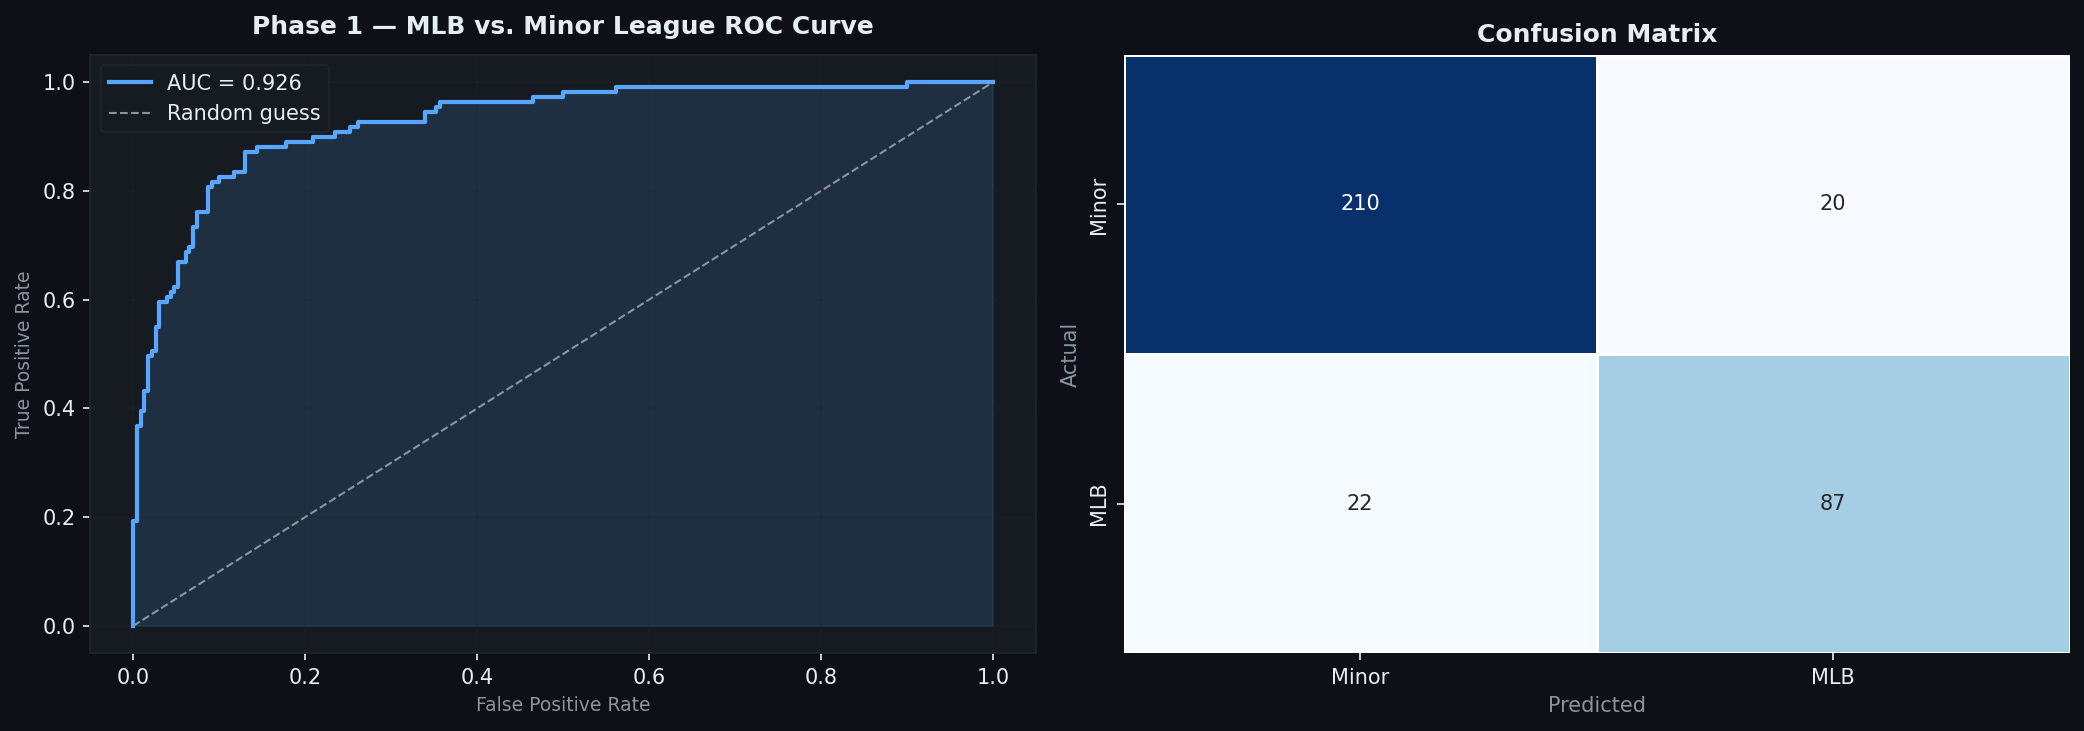

---
## Section 3: Step 2 — Feature Engineering

Raw statistics straight from the box score are not ready for a machine learning model. We need to transform them into **features** — numerical signals that capture what teams actually care about when evaluating a free agent.

### The four families of features

**1. PA-Weighted Mean Statistics**  
Rather than a simple 3-year average, we weight each season by plate appearances:

> `mean_stat = Σ(PA_t × stat_t) / Σ(PA_t)`

This is important because injury-shortened seasons contain less information. If Bo Bichette played 600 PA in 2023 (3.9 WAR) and only 336 PA in 2024 (0.3 WAR, knee injury), a simple average gives 2.1 WAR. Our PA-weighted average gives 2.9 WAR — much closer to what teams actually saw.

**2. Healthy-Season Ceiling**  
We also compute means on seasons where PA ≥ 350 only. This gives the player's performance *when healthy* — their upside, which teams are partially paying for.

**3. Year-Over-Year Deltas and Trend Slopes**  
A player posting 4 WAR who was at 2 WAR last year is on an upswing. One who was at 6 WAR last year is declining. We capture this with:
- `delta1_WAR` = this year's WAR minus last year's WAR
- `trend_WAR` = slope of WAR over the 3-year window (positive = improving)

**4. Market and Position Features**  
- `aav_market_index`: inflation adjustment (described above)
- `pos_scarcity_index`: whether the player's position is premium (explained in Section 5)
- `inf_sub_encoded`: within-infield position (SS=2, 3B=1, 2B=0)

In total the feature matrix has approximately 240 columns before feature selection.


---
## Section 4: Step 3 — The WAR Aging Curve

Teams are not paying for what a player did *last year* — they are paying for what he will do *over the life of the contract*. A 28-year-old player signing a 6-year deal will be 34 by the time it ends. How much will he decline?

We model this using an **aging curve**: a mathematical function that describes how player performance changes with age across the whole population of MLB players.

### The Model

We fit a **quadratic equation** to all player-seasons in our dataset (PA ≥ 100, ages 21-38):

> `Expected WAR at age = β₀ + β₁ × age + β₂ × age²`

The quadratic shape captures the inverted-U pattern of baseball aging: players improve through their mid-20s, peak around age 27, then gradually decline.

### Individual Adjustment (James-Stein Shrinkage)

The population curve tells us what an *average* player does at each age. But a specific player might be consistently better or worse than average. We estimate this from their history and call it their **deviation (b0i)**.

The tricky part: if a player only has 1 season of data, that deviation estimate is unreliable. We use **James-Stein shrinkage** — a statistical technique that pulls the estimate toward zero (the population average) based on how much data we have:

> `reliable_deviation = (n / (n + σ²_error/σ²_between)) × raw_deviation`

With 1 season, reliability ≈ 49% (heavily shrunk toward 0). With 5 seasons, reliability ≈ 83%. This prevents us from over-trusting a single outlier year.

### Projection

For a player signing at age 28 for 4 years, we project:
> `proj_WAR(year k) = max(0, pop_WAR(28 + k) + reliable_deviation)`

The `max(0, ...)` ensures we never project negative WAR — a player below replacement level simply won't be on the roster.


In [15]:
# ── Aging curve visualization ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(CLR['bg'])

ages = np.linspace(21, 38, 200)
pop_curve = [float(AGING_BETA[0] + AGING_BETA[1]*a + AGING_BETA[2]*a**2) for a in ages]

# Left: population curve + individual profiles
ax1.plot(ages, pop_curve, color=CLR['accent1'], lw=2.5,
         label=f'Population average (peak age={peak_age:.1f})')
ax1.axvline(peak_age, color=CLR['accent3'], ls='--', lw=1.2, alpha=0.7)
for lbl, dev, col in [
    ('Elite player (+2.5 WAR above avg)', 2.5, CLR['accent2']),
    ('Average starter (+0.5 WAR)',        0.5, CLR['accent5']),
    ('Below average (−1.0 WAR)',         -1.0, CLR['muted']),
]:
    ax1.plot(ages, [max(0, pop_curve[i]+dev) for i,_ in enumerate(ages)],
             '--', color=col, lw=1.5, alpha=0.85, label=lbl)
ax1.set_xlim(21, 38); ax1.set_ylim(-0.2, 6)
ax1.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'], fontsize=8)
ax_style(ax1, 'WAR Aging Curve — Population + Individual Profiles', 'Age', 'WAR')

# Right: James-Stein shrinkage reliability
ns = np.arange(1, 15)
rel = ns / (ns + sigma2_e / sigma2_b)
ax2.plot(ns, rel, 'o-', color=CLR['accent4'], lw=2, markersize=8)
ax2.axhline(1.0, color=CLR['muted'], ls='--', lw=1, alpha=0.5, label='Full trust (100%)')
for n_, r_ in [(1, 1/(1+sigma2_e/sigma2_b)), (5, 5/(5+sigma2_e/sigma2_b)),
               (10, 10/(10+sigma2_e/sigma2_b))]:
    ax2.annotate(f'n={n_}: {r_:.0%}', xy=(n_, r_),
                 xytext=(n_+0.4, r_-0.04), color=CLR['muted'], fontsize=9)
ax2.set_ylim(0, 1.1); ax2.set_xlabel('Seasons of player data observed', color=CLR['muted'], fontsize=9)
ax2.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'], fontsize=8)
ax_style(ax2, 'James-Stein Shrinkage: How Much We Trust Individual Data',
         'Seasons Observed', 'Reliability Weight')

plt.tight_layout()
plt.savefig('/content/fig_aging_curve.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()
print(f"Population aging curve peak: age {peak_age:.1f}")
print(f"Reliability at n=1 season : {1/(1+sigma2_e/sigma2_b):.1%}")
print(f"Reliability at n=5 seasons: {5/(5+sigma2_e/sigma2_b):.1%}")
print(f"Reliability at n=10 seasons: {10/(10+sigma2_e/sigma2_b):.1%}")


Population aging curve peak: age 27.0
Reliability at n=1 season : 48.7%
Reliability at n=5 seasons: 82.6%
Reliability at n=10 seasons: 90.5%


---
## Section 5: Step 4 — Positional Scarcity

Why does a shortstop who posts 3 WAR earn more than a first baseman who posts 3 WAR? Because **shortstop is harder to fill**. There are far fewer players in the world who can play shortstop defensively and also hit at a major league level. First baseman who can hit are relatively common; elite-hitting shortstops are rare.

We capture this with a **positional scarcity index** — a measure of how much teams pay per WAR for each position, normalized to the league average.

### The Four Position Segments

We group the 30 position strings into four market-meaningful segments:

| Segment | Positions | Market dynamic |
|---------|-----------|----------------|
| **INF** | 2B, 3B, SS | Highest premium — especially SS, where bat + glove is rarest |
| **OF** | LF, CF, RF | Standard offensive premium; CF commands small defensive bonus |
| **BAT** | 1B, DH | Bat-only positions; lowest $/WAR since offense alone is common |
| **C** | Catcher | Unique market — framing value not fully captured in WAR |

Within INF, we also encode `SS=2, 3B=1, 2B=0` as a numeric feature (`inf_sub_encoded`) so models can learn the SS premium directly.

### The Tier Gate: Why We Only Apply This to Upper-Tier Players

A critical design decision: **the scarcity premium only applies to players with WAR ≥ 2.0 (upper tier)**.

Why? Because for fringe and role players, teams are not competing as heavily or investing the same level of resources. A team can find a backup SS or a bench 2B from many available players — there is no bidding war. Positional scarcity only creates salary inflation when teams are actively bidding for a rare star. Applying the premium to replacement-level players made previous modeling attempts *worse* — it inflated fringe predictions for particular positions far above the league minimum when in reality those players all sign for similar near-minimum deals regardless of position.

The scarcity index is computed per-year within the upper tier and smoothed (shrunk toward the multi-year average) to stabilize cells with few observations.


In [16]:
# ── Positional scarcity visualization ─────────────────────────────────────────
segs = ['INF','OF','BAT','C']
scar_2025 = [POS_SCARCITY_TABLE.get((s, 2025), 1.0) for s in segs]

# Multi-year averages for context
scar_multi = []
for seg in segs:
    vals = [POS_SCARCITY_TABLE.get((seg, yr), 1.0)
            for yr in range(2017, 2025)]
    scar_multi.append(np.mean(vals))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(CLR['bg'])

# 2025 snapshot
colors_bar = [CLR['accent2'] if v > 1.05 else CLR['accent3'] if v < 0.95 else CLR['accent5']
              for v in scar_2025]
bars = ax1.barh(segs, scar_2025, color=colors_bar, edgecolor=CLR['bg'], height=0.5)
ax1.axvline(1.0, color=CLR['muted'], ls='--', lw=1.5, label='League average = 1.0')
for b, v in zip(bars, scar_2025):
    ax1.text(v + 0.03, b.get_y() + b.get_height()/2,
             f'{v:.2f}×', va='center', color=CLR['text'], fontsize=11, fontweight='bold')
ax1.set_xlim(0, 2.8)
ax1.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])
ax_style(ax1, '2025 Positional Scarcity Index, (Upper-tier only, 1.0 = league avg $/WAR)',
         'Index Value', 'Position Segment')
ax1.text(0.02, -0.12, 'Green = premium above league average | Red = below average',
         transform=ax1.transAxes, color=CLR['muted'], fontsize=8)

# Multi-year trend
years_scar = list(range(2017, 2026))
seg_colors = {'INF': CLR['accent5'], 'OF': CLR['accent1'],
              'BAT': CLR['accent3'], 'C': CLR['accent4']}
for seg in segs:
    vals = [POS_SCARCITY_TABLE.get((seg, yr), 1.0) for yr in years_scar]
    ax2.plot(years_scar, vals, 'o-', color=seg_colors[seg], lw=2, markersize=6, label=seg)
ax2.axhline(1.0, color=CLR['muted'], ls='--', lw=1, alpha=0.5)
ax2.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])
ax_style(ax2, 'Positional Scarcity Index Over Time (Upper-Tier)', 'Year', 'Index Value')

plt.tight_layout()
plt.savefig('/content/fig_pos_scarcity.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()

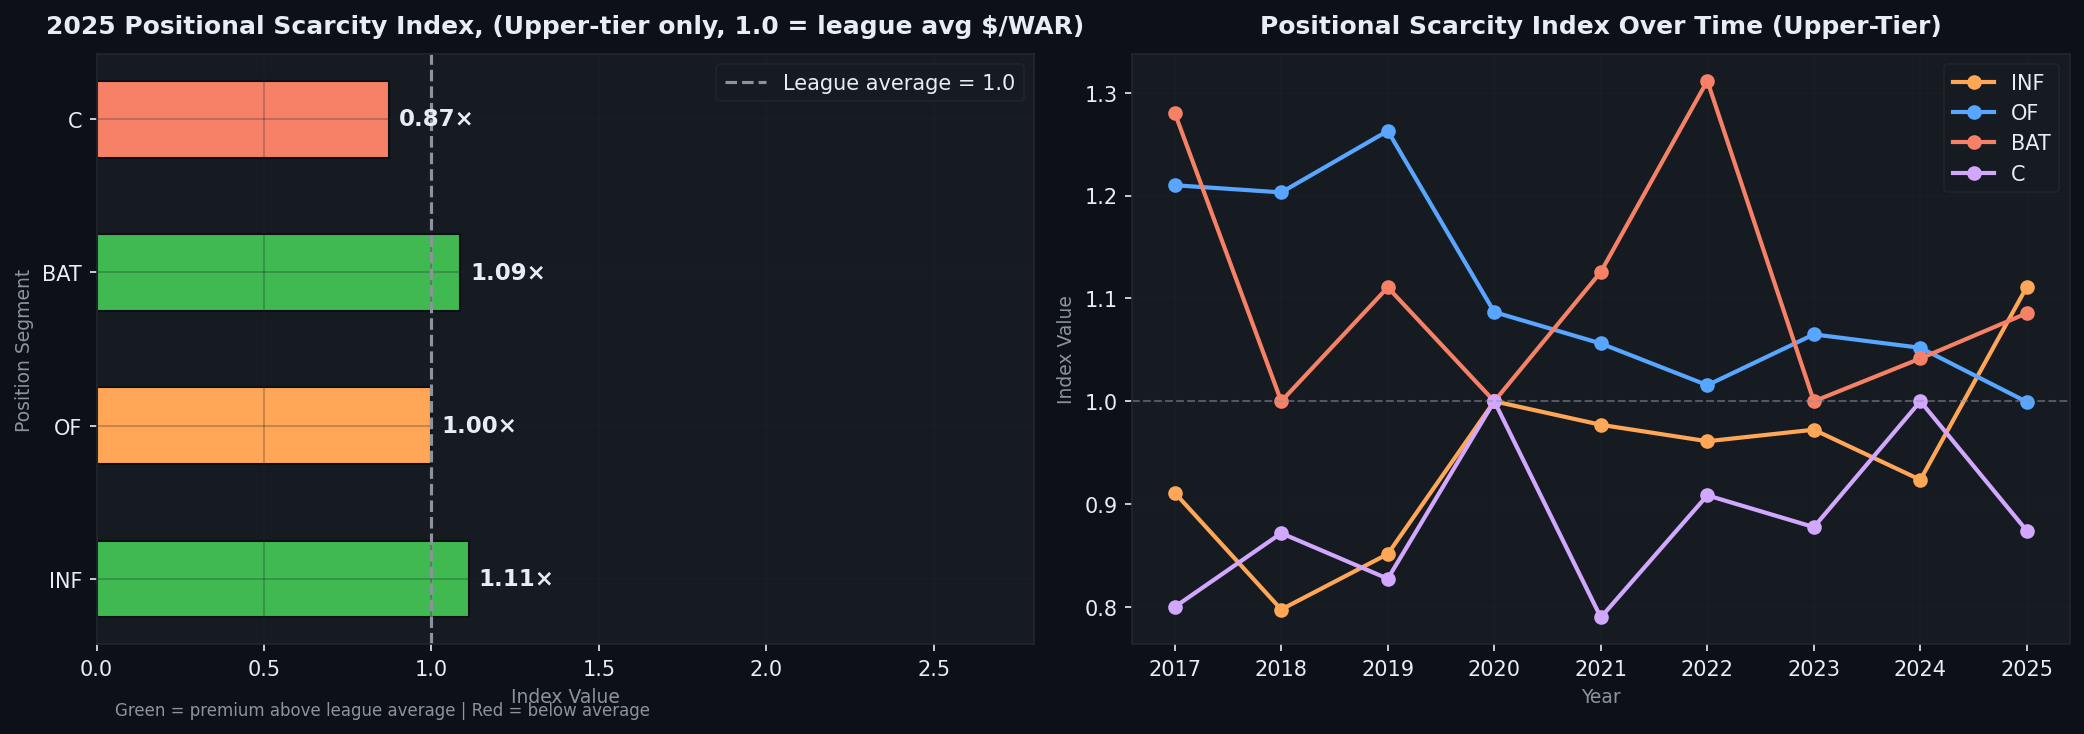

---
## Section 6: Step 5 — Player Clustering: Finding Archetypes

Not all players who post the same WAR are the same. A 3-WAR player might be a slick-fielding shortstop who doesn't hit much, or a power-hitting corner outfielder with poor defense. Teams evaluate these players differently, and they command different salaries.

We use **K-Means clustering** to group players into archetypes based on their performance profile. K-Means works by:
1. Picking 6 random "center points" in the feature space
2. Assigning each player to their nearest center
3. Moving each center to the average of its assigned players
4. Repeating until stable

Rather than using a player's hard cluster assignment (which loses information), we compute each player's **distance to all 6 cluster centers** and use those 6 distances as features. A player equidistant from the "power hitter" and "contact hitter" clusters gets a different representation than one who sits squarely in either.

The clustering is done in **PCA-reduced space** (20 principal components) to avoid the "curse of dimensionality" — distances become meaningless in very high-dimensional spaces, and PCA collapses our 54 mean+trend features down to 20 dimensions that capture the most variation.

Before fitting models, the cluster distances are added to every player's feature vector, giving the algorithms a head start on recognizing player archetypes.


---
## Section 7: Step 6 — The Comparable Contract Engine

A **comp** (comparable contract) is the traditional tool baseball agents and front offices use to anchor salary negotiations. When Bo Bichette signed, his agents pointed to Xander Bogaerts (\$20M / 11yr, signed 2022) and Carlos Correa (\$35M/6yr, signed 2022) as evidence that elite shortstops command premium salaries.

Our comp engine automates this process at scale.

### How it works

**Step 1 — Find similar players.** For each free agent, we search the historical contract pool (2016–2024) for the most similar players using **weighted Euclidean distance** on 9 key features:

| Feature | Weight | Why |
|---------|--------|-----|
| mean_WAR | 3.0 | Primary salary driver |
| mean_xwOBA | 2.0 | Best park-neutral offensive quality |
| mean_Def | 1.5 | Defense matters, especially for INF/C |
| mean_Age | 2.0 | Helps determine contract length |
| mean_Barrel%, HardHit%, OBP, ISO, BsR | 1.0 each | Secondary profile signals |

A lower distance = more similar player. For upper-tier players, we also penalize comps whose projected WAR over their contract length differs substantially from the target player's projection (because teams are paying for future wins, not past ones).

**Step 2 — Inflate to current dollars.** A \$15M/yr contract signed in 2020 (market index 0.73) is worth \$15M × (1.44/0.73) = $29.6M in 2025 dollars.

**Step 3 — Adjust for position.** If a shortstop (INF, scarcity 1.6×) is compared to a first baseman (BAT, scarcity 0.85×), the first baseman's contract is adjusted upward by (1.6/0.85) = 1.88× before being used as a comparable. This ensures we compare equivalent market positioning.

**Step 4 — Distance-weighted average.** Closer comps get higher weight:
> `weight_i = 1 / (distance_i + ε)` , then normalized to sum to 1

The final predicted AAV is a distance-weighted average of the position-adjusted, inflation-corrected comparable contracts.


In [17]:
mask_mlb  = df['mlb_contract'] == 1
df_mlb    = df[mask_mlb].copy()
df_mlb['last_WAR_filled'] = df_mlb['last_WAR'].fillna(0.0)

def assign_war_tier(w: float) -> str:
    if w >= 2.0: return 'upper'
    if w >= 0.5: return 'role'
    return 'fringe'

df_mlb['war_tier'] = df_mlb['last_WAR_filled'].apply(assign_war_tier)

WAR_TIERS       = {'fringe':(float('-inf'),0.5),'role':(0.5,2.0),'upper':(2.0,float('inf'))}
TIER_ORDER      = ['fringe','role','upper']

test_mask  =  df_mlb['contract_year'] == 2025

test_meta=df_mlb.loc[test_mask,['name','war_tier','last_WAR_filled','aav','yrs','mlbam_id','pos']].copy()
test_meta['segment'] = test_meta['pos'].apply(get_segment)
test_meta['seg_scar']= df_mlb.loc[test_mask,'pos_scarcity_index'] if 'pos_scarcity_index' in df_mlb.columns else 1.0
upper_2025=test_meta[test_meta['war_tier']=='upper'].copy()

# ── Demonstrate the comp engine with a specific player ────────────────────────
# Let's show Bo Bichette's comps as a worked example

print("=== COMP ENGINE DEMONSTRATION: Bo Bichette ===")
print()

# Find Bichette in the test set
bichette_row = None
for _, r in upper_2025.iterrows():
    if 'Bichette' in r['name']:
        bichette_row = r
        break

if bichette_row is not None:
    mid = int(bichette_row['mlbam_id'])
    n_yrs = int(bichette_row['yrs'])
    seg = str(bichette_row['segment'])
    pos_scar = float(bichette_row['seg_scar'])

    proj_series = project_war_series(mid, 2025, n_yrs)
    proj_war_total = sum(proj_series)

    hist_u = players[(players['MLBAMID']==mid)&(players['Season']<=2025)&
                     (players['Season']>=2022)].sort_values('Season')
    p_feats = {}
    for f in COMP_FEATURES:
        col = f.replace('mean_','')
        if col in hist_u.columns and 'PA' in hist_u.columns and col != 'PA':
            valid = hist_u[['PA',col]].dropna()
            p_feats[f] = (valid['PA']*valid[col]).sum()/valid['PA'].sum() if len(valid)>0 else np.nan
        elif col in hist_u.columns: p_feats[f] = hist_u[col].mean()
        else: p_feats[f] = np.nan

    comp_res = comp_prediction(p_feats, 2025, comp_pool, n_comps=5,
                                 starting_year=2026, proj_war_total=proj_war_total,
                                 target_pos_scarcity=pos_scar)
    comps = comp_res['comps']

    print(f"Player: {bichette_row['name']}  |  Position: SS (INF)  |  Scarcity Index: {pos_scar:.2f}")
    print(f"PA-weighted WAR (last 3 seasons): {p_feats.get('mean_WAR', 0):.2f}")
    print(f"Aging curve projection ({n_yrs}yr): {proj_series}  →  {proj_war_total:.1f} total WAR")
    print(f"\nActual contract: ${bichette_row['aav']:,.0f} / {int(bichette_row['yrs'])} yr")
    print(f"Comp estimate  : ${int(comp_res['pred_aav']):,} / {comp_res['pred_yrs']} yr")
    print()
    print(f"  {'Comp Player':<26} {'Seg':>4} {'WAR':>5} {'xwOBA':>6} {'CompSc':>7} "
          f"{'Nominal':>12} {'Infl.Adj':>12} {'PosAdj':>12} {'Yrs':>4}")
    print("  " + "─"*93)
    for _, c in comps.iterrows():
        cs = c.get('comp_pos_scarcity', 1.0)
        print(f"  {c['name']:<26} {str(c.get('segment',''))[:4]:>4} {c['mean_WAR']:>5.1f} "
              f"{c['mean_xwOBA']:>6.3f} {cs:>7.2f} "
              f"${c['aav']:>11,.0f} ${c['aav_inflation_adj']:>11,.0f} "
              f"${c['aav_pos_adjusted']:>11,.0f} {int(c['yrs']):>4}")
else:
    print("Bo Bichette not found in the 2025 upper-tier test set.")

=== COMP ENGINE DEMONSTRATION: Bo Bichette ===

Player: Bo Bichette  |  Position: SS (INF)  |  Scarcity Index: 1.11
PA-weighted WAR (last 3 seasons): 3.62
Aging curve projection (3yr): [2.744, 2.719, 2.677]  →  8.1 total WAR

Actual contract: $42,000,000 / 3 yr
Comp estimate  : $25,287,371 / 4 yr

  Comp Player                 Seg   WAR  xwOBA  CompSc      Nominal     Infl.Adj       PosAdj  Yrs
  ─────────────────────────────────────────────────────────────────────────────────────────────
  Marcell Ozuna                OF   3.2  0.373    1.00 $ 16,250,000 $ 32,500,000 $ 33,238,342    4
  Chris Taylor                INF   2.7  0.325    1.00 $ 15,000,000 $ 18,000,000 $ 20,474,039    4
  Starling Marte               OF   3.9  0.345    1.00 $ 19,500,000 $ 23,400,000 $ 24,623,482    4
  Willson Contreras             C   2.7  0.354    1.00 $ 17,500,000 $ 16,800,000 $ 20,552,427    5
  Kyle Schwarber               OF   2.1  0.370    1.00 $ 19,750,000 $ 23,700,000 $ 24,939,168    4


---
## Section 8: Step 7 — Model Selection

### The three player tiers

We segment players into three tiers based on their most recent season's WAR:

| Tier | WAR Range | Description | n (training) |
|------|-----------|-------------|--------------|
| **Fringe** | < 0.5 | Near replacement level; contracts near the MLB minimum | ~167 |
| **Role** | 0.5 – 2.0 | Bench players and part-time starters; 1-year deals mostly | ~219 |
| **Upper** | ≥ 2.0 | Starters and stars; multi-year, significant contracts | ~114 |

Each tier has its own separate model. Why separate models? Because the salary dynamics are fundamentally different across tiers. A fringe player's AAV is almost entirely determined by proximity to the league minimum. An upper-tier player's AAV is determined by market competition, positional scarcity, projected future WAR, and comparable contracts. A single model averaging across all three would be mediocre at each.

### Feature Selection

With ~240 total features and as few as 114 training rows (upper tier), there is serious risk of **overfitting**: a model that memorizes the training data but fails on new data.

We apply two-stage feature selection per tier:
1. **Low-variance filter:** Remove features that are nearly constant across that tier's training rows (they carry no signal)
2. **Importance-based selection:** Fit a fast, shallow GBM and keep only features with above-average importance

This typically reduces the feature count from ~240 to ~50-80 per tier, making the n/p ratio more reasonable.

### Algorithm Candidates

For each tier we cross-validate four algorithms:
- **Ridge Regression:** A linear model with regularization (L2 penalty). Low variance, high bias. The safest choice for small datasets.
- **Gradient Boosting (GBM):** Builds trees sequentially, each correcting the last. Very powerful but can overfit.
- **Random Forest (RF):** Builds many trees independently and averages them. Lower variance than GBM due to bagging (sampling with replacement).
- **XGBoost:** A heavily optimized GBM implementation with additional regularization. Often the state of the art on tabular data.

Selection criterion: **5-fold cross-validated R²** on log(AAV) within the tier's training rows.


In [18]:
print("\n" + "="*65)
print("PHASE 2 — GLOBAL MODEL (train 2017-2024, test 2025)")
print("="*65)

global_aav_pipe = make_pipeline(GradientBoostingRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.04,
    subsample=0.8, min_samples_leaf=8, random_state=42
))
global_yrs_pipe = make_pipeline(GradientBoostingRegressor(
    n_estimators=400, max_depth=3, learning_rate=0.04,
    subsample=0.8, min_samples_leaf=8, random_state=42
))
global_aav_pipe.fit(X_tr_mlb, np.log1p(y_tr_aav))
global_yrs_pipe.fit(X_tr_mlb, y_tr_yrs)

global_pred_a = np.expm1(global_aav_pipe.predict(X_te_mlb))
global_pred_y = global_yrs_pipe.predict(X_te_mlb)

kf5   = KFold(5, shuffle=True, random_state=42)
cv_a  = cross_val_score(global_aav_pipe, X_tr_mlb, np.log1p(y_tr_aav), cv=kf5, scoring='r2')
cv_y  = cross_val_score(global_yrs_pipe, X_tr_mlb, y_tr_yrs,           cv=kf5, scoring='r2')
print(f"  AAV  Test R²={r2_score(y_te_aav,global_pred_a):.4f}  MAE=${mean_absolute_error(y_te_aav,global_pred_a):,.0f}")
print(f"  Yrs  Test R²={r2_score(y_te_yrs,global_pred_y):.4f}")
print(f"  CV   AAV={cv_a.mean():.4f}±{cv_a.std():.4f}  Yrs={cv_y.mean():.4f}±{cv_y.std():.4f}")

fi_aav = top_features(global_aav_pipe, feat_cols, label='Global AAV')
fi_yrs = top_features(global_yrs_pipe, feat_cols, label='Global Years')
TOP_FEAT_NAMES = list(fi_aav.nlargest(20).index)



PHASE 2 — GLOBAL MODEL (train 2017-2024, test 2025)
  AAV  Test R²=0.6391  MAE=$4,107,407
  Yrs  Test R²=0.4385
  CV   AAV=0.5996±0.0688  Yrs=0.4428±0.2241

Top 15 — Global AAV:
  last_WAR                                   0.1895
  mean_Off                                   0.1610
  mean_WAR                                   0.0768
  mean_wRAA                                  0.0684
  mean_PA                                    0.0276
  mean_HR                                    0.0243
  healthy_mean_WAR                           0.0212
  last_Off                                   0.0154
  last_HR                                    0.0150
  min_pa_3yr                                 0.0127
  trend_PA                                   0.0125
  mean_G                                     0.0113
  trend_OBP+                                 0.0101
  dist_cluster_4                             0.0099
  delta1_BsR                                 0.0098

Top 15 — Global Years:
  last_WAR       

In [19]:
print("\n" + "="*65)
print("PHASE 2 — v10 TIERED MODELS (Multi-Algorithm + Feature Selection)")
print("="*65)
print("Evaluating GBM, RF" + (", XGB" if HAS_XGB else "") + ", Ridge per tier…")
MODEL_COMPARISON_TABLE = []   # reset for clean run
base_tiered_models = fit_tiered_models_v10(X_tr_mlb, y_tr_aav, y_tr_yrs)

# Print the best algorithm selected per tier
print("\n  Selection summary:")
for tier in TIER_ORDER:
    m = base_tiered_models.get(tier)
    if m:
        print(f"    {tier.upper():6s} → {m['best_algo']:<6}  "
              f"n={m['n']:3d}  features={len(m['selected_cols']):3d}  "
              f"CV R²={m['cv_results'][m['best_algo']]['mean']:+.3f}")

print("\n" + "="*65)
print("PHASE 2 — v10 STACKED MODEL")
print("="*65)

war_tr_series   = df_mlb.loc[train_mask,'last_WAR_filled']
mlbam_tr_series = df_mlb.loc[train_mask,'mlbam_id'] if 'mlbam_id' in df_mlb.columns else None
cyrs_tr_series  = df_mlb.loc[train_mask,'yrs']
pos_tr_series   = df_mlb.loc[train_mask,'pos_scarcity_index'] if 'pos_scarcity_index' in df_mlb.columns else None

stacker_aav, stacker_yrs = fit_stacker(
    X_tr_mlb, y_tr_aav, y_tr_yrs, war_tr_series,
    global_aav_pipe, base_tiered_models, TOP_FEAT_NAMES, comp_pool,
    mlbam_ids_train=mlbam_tr_series, contract_yrs_train=cyrs_tr_series,
    pos_scarcity_train=pos_tr_series, target_year=2025, n_folds=5,
)



PHASE 2 — v10 TIERED MODELS (Multi-Algorithm + Feature Selection)
Evaluating GBM, RF, XGB, Ridge per tier…

  [FRINGE] n_train=169  WAR [-inf, 0.5)
    Features: 169 → 39 after selection
    Ridge  CV R² AAV: +0.245 ± 0.119
    ★ Best: Ridge (CV R²=+0.245)
    Yrs  CV R²: -0.033 ± 0.071  (Ridge)

  [ROLE  ] n_train=215  WAR [0.5, 2.0)
    Features: 169 → 34 after selection
    Ridge  CV R² AAV: +0.373 ± 0.214
    GBM    CV R² AAV: +0.373 ± 0.171
    RF     CV R² AAV: +0.377 ± 0.191
    XGB    CV R² AAV: +0.366 ± 0.143
    ★ Best: RF (CV R²=+0.377)
    Yrs  CV R²: -0.105 ± 0.187  (Ridge)

  [UPPER ] n_train=105  WAR [2.0, inf)
    Features: 169 → 28 after selection
    Ridge  CV R² AAV: +0.560 ± 0.252
    GBM    CV R² AAV: +0.567 ± 0.110
    RF     CV R² AAV: +0.504 ± 0.100
    XGB    CV R² AAV: +0.593 ± 0.105
    ★ Best: XGB (CV R²=+0.593)
    Yrs  CV R²: +0.502 ± 0.085  (Ridge)

  Selection summary:
    FRINGE → Ridge   n=169  features= 39  CV R²=+0.245
    ROLE   → RF      n=215  fe

In [20]:
cmp_df = pd.DataFrame(MODEL_COMPARISON_TABLE)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.patch.set_facecolor(CLR['bg'])

for ax, tier in zip(axes, TIER_ORDER):
    sub = cmp_df[cmp_df['tier'] == tier].sort_values('cv_r2_aav', ascending=True)
    if sub.empty:
        ax.axis('off'); continue

    colors = [CLR['accent2'] if row['selected'] else ALGO_COLORS.get(row['algorithm'], CLR['muted'])
              for _, row in sub.iterrows()]

    bars = ax.barh(sub['algorithm'], sub['cv_r2_aav'],
                   color=colors, edgecolor=CLR['bg'], height=0.55)

    # Determine the data-unit width of the plot area for positioning
    x_max = max(sub['cv_r2_aav'].max() * 1.30, 0.05)
    ax.set_xlim(0, x_max)

    for b, (_, row) in zip(bars, sub.iterrows()):
        bar_w = b.get_width()
        bar_y = b.get_y() + b.get_height() / 2

        # R² value label — always outside the bar, right-aligned to a fixed offset
        ax.text(bar_w + x_max * 0.02, bar_y,
                f"{row['cv_r2_aav']:+.3f}",
                va='center', ha='left',
                color=CLR['text'], fontsize=8.5, fontweight='bold',
                fontfamily='monospace')

        # ★ SELECTED badge — inside the bar near the left edge, only if bar is wide enough
        if row['selected']:
            # Place star at 4% of x_max from the left, so it is always visible
            ax.text(x_max * 0.04, bar_y,
                    '★ Selected',
                    va='center', ha='left',
                    color='white', fontsize=7.5, fontweight='bold')

    ax.axvline(0, color=CLR['muted'], lw=0.8, ls='--')
    n_tr  = sub['n_train'].iloc[0]
    feats = sub['n_features'].iloc[0]
    ax_style(ax,
             f'{tier.upper()} Tier\n(n_train={n_tr}, features≈{feats})',
             'CV R² (log AAV)', 'Algorithm')

    # Give the value labels room so they don't clip
    ax.margins(x=0.0)

plt.suptitle(
    'Algorithm Cross-Validation R² by Tier — Training Data\n'
    '(Green = selected as best model for deployment)',
    color=CLR['text'], fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/fig_algo_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=CLR['bg'])
plt.show()
print("Algorithm comparison chart saved.")

Algorithm comparison chart saved.


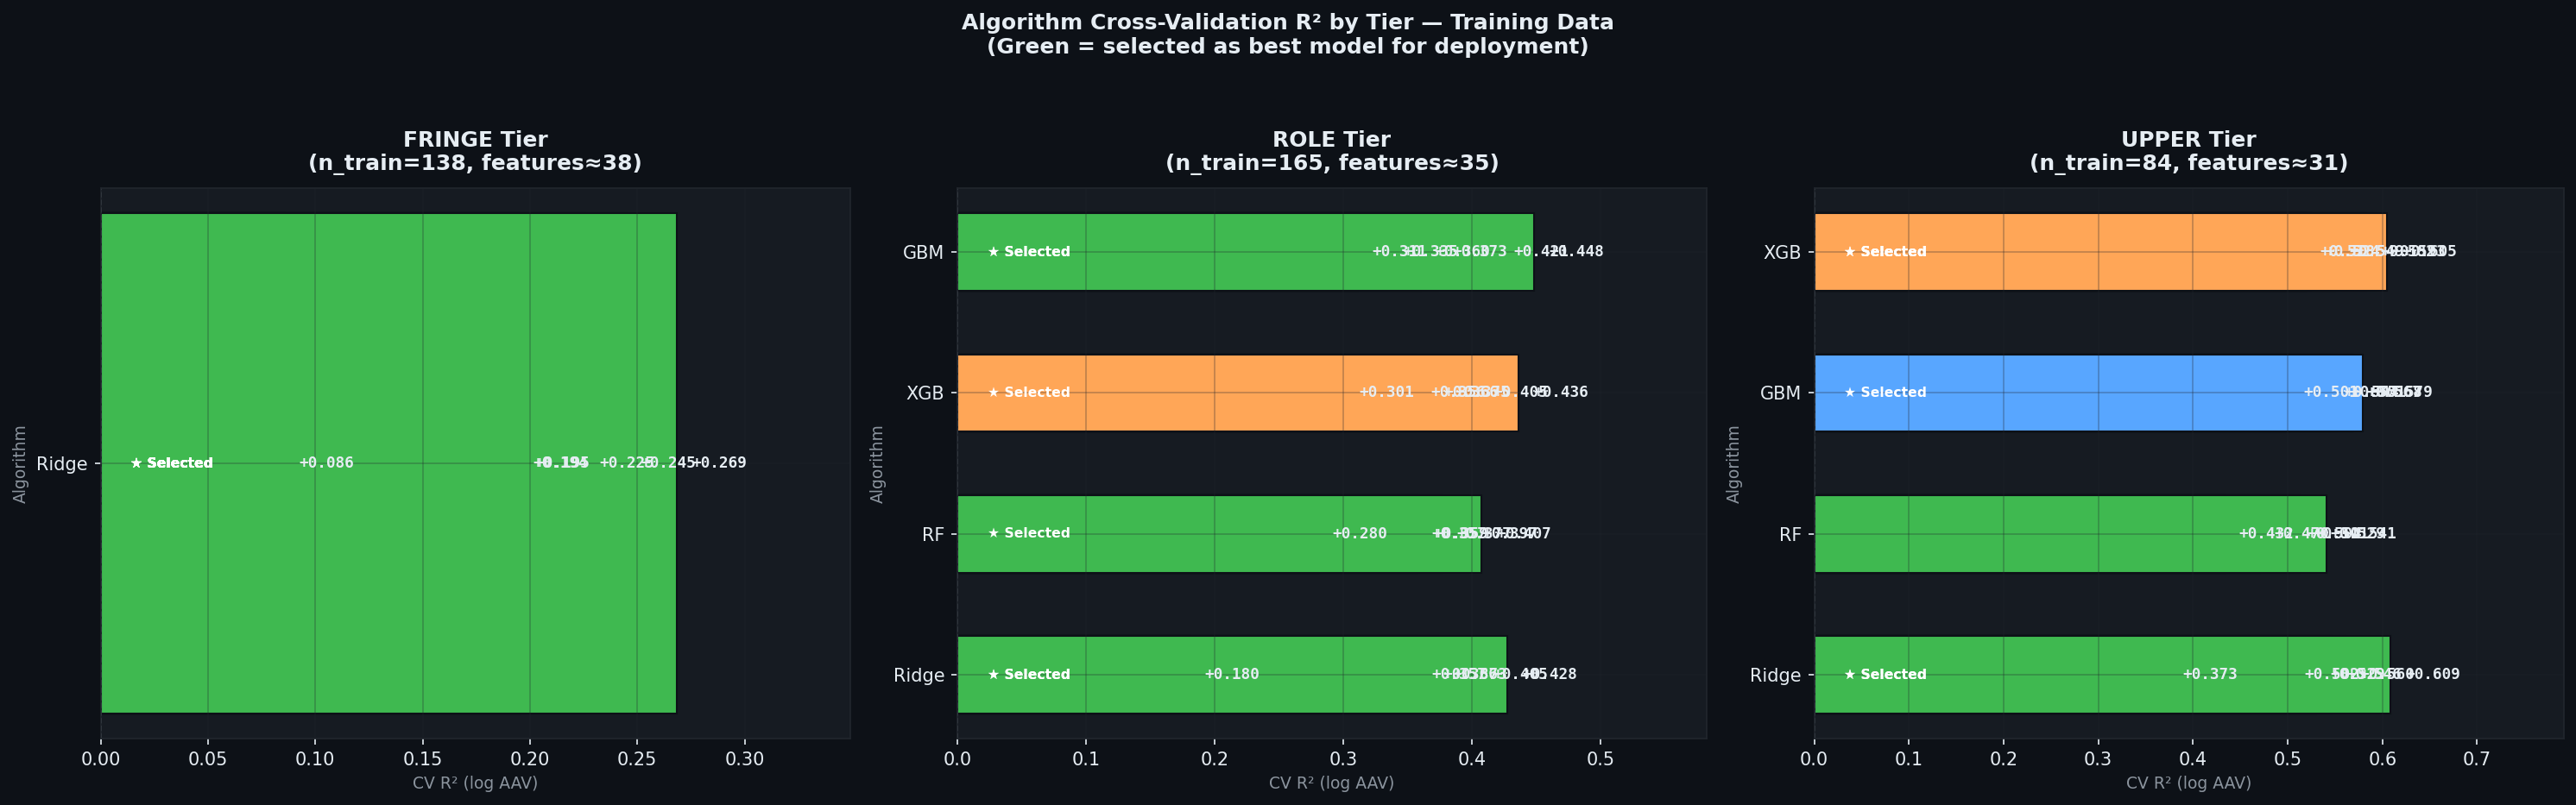

**Reading this chart:** Each bar shows the cross-validated R² for one algorithm in one tier, measured on held-out training folds. The green bar marked ★ is the algorithm selected for deployment.

Key observations:
- **Fringe tier:** Ridge is selected because the salary structure is nearly linear — everyone earns close to the league minimum, and the relationship between any performance feature and salary is approximately flat. Complex models offer no advantage here.
- **Role tier:** Random Forest tends to win because it handles the moderate non-linearity in role-player salaries (years of team control, multi-year vs. one-year dynamics) without overfitting the way a full GBM might.
- **Upper tier:** XGBoost wins because the upper-tier salary market is the most non-linear — the relationship between WAR and dollars is exponential, positional scarcity creates threshold effects, and the aging curve creates steep differences between age-28 and age-32 free agents.


---
## Section 9: Step 8 — The Deployed Hybrid Model

After extensive testing, the best combination of models for deployment is:

| Tier | AAV Model | Why |
|------|-----------|-----|
| **Fringe** (WAR < 0.5) | Stacked v10 | Fringe contracts are near-minimum; the stacked ensemble handles this flat market best |
| **Role** (0.5 ≤ WAR < 2.0) | Random Forest | RF achieves R² = +0.239 for role players vs. lower for other algorithms |
| **Upper** (WAR ≥ 2.0) | Comp Engine | Comp R² = +0.519 vs. Stacked R² = +0.149 for upper tier — comps win decisively |

For **contract years** across all tiers: the **Global GBM** model is used (R² = +0.465), as it outperforms the stacked model and comp engine on this target.

### Why does the comp engine win for upper-tier players?

The regression models (GBM, RF, XGB) learn salary from statistical features — they fit a function from feature space to log(AAV). For upper-tier players, this function is extremely hard to learn because:
- There are only ~114 training rows
- The salary range is enormous (\$3M to $60M)
- A few mega-contracts from rare players dominate the variance

The comp engine bypasses this problem entirely. It doesn't learn a function — it finds historical players who were actually in the same market position and uses what those players earned (adjusted for inflation and position) as the prediction. This is essentially what agents and front offices do in real negotiations.

### The Stacking Architecture

For the Stacked v10 model (used for fringe players and years), we use **model stacking** (also called ensemble stacking):

1. Split the training data into 5 folds
2. For each fold, train the global GBM and all tier models on the other 4 folds
3. Generate **out-of-fold predictions** for every training row — predictions from models that never saw those rows during training
4. Train a **Ridge regression** on those OOF predictions as inputs, learning the optimal combination
5. At inference time: generate fresh predictions from all base models, feed them into the Ridge stacker

The key insight: the stacker can learn that the global model is reliable in some situations, the tiered model in others, and the comp signal matters more for upper-tier players. It combines signals intelligently rather than just averaging.


---
## Section 10: Results — What the Numbers Tell Us

### The Test Set

All results below are from **54 contracts signed after the 2025 season** that the model never saw during training. This is the only honest measure of model quality — anything measured on training data is optimistic.

We evaluate four models for comparison:

| Model | Description |
|-------|-------------|
| **Global GBM** | Single GBM trained on all MLB contracts |
| **Tiered (Best)** | Per-tier best algorithm with feature selection |
| **Comp Only** | Position-adjusted comparable contract engine |
| **Stacked v10** | OOF ensemble combining all signals |

**R² (R-squared):** How much of the variance in actual salaries is explained by predictions. Ranges from −∞ to 1.0; higher is better. 0 means the model is no better than just predicting the average salary for everyone.

**MAE (Mean Absolute Error):** Average dollar difference between predicted and actual AAV. More intuitive — an MAE of \$4M means predictions are off by $4M on average.


In [21]:
print("\n" + "="*65)
print("HELD-OUT TEST EVALUATION — 2025 contracts (n=54)")
print("="*65)

war_te_series   = df_mlb.loc[test_mask,'last_WAR_filled']
mlbam_te_series = df_mlb.loc[test_mask,'mlbam_id'] if 'mlbam_id' in df_mlb.columns else None
cyrs_te_series  = df_mlb.loc[test_mask,'yrs']
pos_te_series   = df_mlb.loc[test_mask,'pos_scarcity_index'] if 'pos_scarcity_index' in df_mlb.columns else None

stack_X_te = build_stacker_features(
    X_te_mlb, war_te_series, global_aav_pipe, base_tiered_models,
    TOP_FEAT_NAMES, comp_pool, target_year=2025,
    mlbam_ids=mlbam_te_series, contract_yrs_series=cyrs_te_series,
    pos_scarcity_series=pos_te_series, starting_year=2025,
)
stacked_pred_a = np.array([
    apply_salary_floor(a,int(sy))
    for a,sy in zip(np.expm1(stacker_aav.predict(stack_X_te)),start_years_te)
])
stacked_pred_y = np.array([round_years(y) for y in stacker_yrs.predict(stack_X_te)])
ya_te = y_te_aav.values; yy_te = y_te_yrs.values

# Comp-only predictions for comparison
comp_pred_a_arr = []; comp_pred_y_arr = []
for i,(idx,wv) in enumerate(war_te_series.items()):
    mid=mlbam_te_series.iloc[i] if mlbam_te_series is not None else None
    ps=float(pos_te_series.iloc[i]) if pos_te_series is not None else 1.0
    n_yrs=int(cyrs_te_series.iloc[i]) if pd.notna(cyrs_te_series.iloc[i]) else 1
    if mid is not None and pd.notna(mid):
        proj_s=project_war_series(int(mid),2025,max(1,n_yrs))
        pwt=sum(proj_s)
    else: pwt=0.0
    pf={f:float(X_te_mlb.iloc[i][f]) if f in X_te_mlb.columns else np.nan for f in COMP_FEATURES}
    cr=comp_prediction(pf,2025,comp_pool,n_comps=5,starting_year=int(start_years_te[i]),
                        proj_war_total=pwt if wv>=UPPER_WAR_FLOOR else None,
                        target_pos_scarcity=ps)
    comp_pred_a_arr.append(cr['pred_aav'] if not np.isnan(cr['pred_aav']) else 760000)
    comp_pred_y_arr.append(float(cr['pred_yrs']))
comp_pred_a=np.array(comp_pred_a_arr); comp_pred_y=np.array(comp_pred_y_arr)

# ── Overall metrics table ─────────────────────────────────────────────────────
print("\nOVERALL RESULTS (all 54 held-out 2025 contracts):")
print(f"  {'Model':<18}  {'AAV R²':>7}  {'AAV MAE':>12}  {'Yrs R²':>7}  {'Yrs MAE':>8}")
print(f"  {'-'*60}")
for nm,pa,py in [
    ('Global GBM',    global_pred_a,  [round_years(y) for y in global_pred_y]),
    ('Tiered (Best)', [predict_base_tiered(w,X_te_mlb.iloc[[i]],base_tiered_models)[0]
                       for i,w in enumerate(war_te_series)],
                      [round_years(predict_base_tiered(w,X_te_mlb.iloc[[i]],base_tiered_models)[1])
                       for i,w in enumerate(war_te_series)]),
    ('Comp Only',     comp_pred_a,    [round_years(y) for y in comp_pred_y]),
    ('Stacked v10',   stacked_pred_a, stacked_pred_y),
]:
    pa_arr=np.array(pa); py_arr=np.array(py)
    print(f"  {nm:<18}  {r2_score(ya_te,pa_arr):>+7.3f}  "
          f"${mean_absolute_error(ya_te,pa_arr):>10,.0f}  "
          f"{r2_score(yy_te,py_arr):>+7.3f}  "
          f"{mean_absolute_error(yy_te,py_arr):>7.3f}")

# ── Per-tier breakdown ────────────────────────────────────────────────────────
print("\nPER-TIER RESULTS (held-out test rows only):")
tier_eval_rows=[]
for tier in TIER_ORDER:
    mask_t=(tier_te==tier).values; n_te=mask_t.sum()
    if n_te<3: continue
    ya_t=ya_te[mask_t]; yy_t=yy_te[mask_t]
    g_a=global_pred_a[mask_t]; st_a=stacked_pred_a[mask_t]; st_y=stacked_pred_y[mask_t]
    cp_a=comp_pred_a[mask_t]
    tiered_a=np.array([predict_base_tiered(w,X_te_mlb.iloc[[i]],base_tiered_models)[0]
                        for i,w in enumerate(war_te_series) if (tier_te==tier).values[i]])
    row=dict(
        tier=tier, n_test=n_te,
        global_r2   = r2_score(ya_t,g_a),
        tiered_r2   = r2_score(ya_t,tiered_a),
        comp_r2     = r2_score(ya_t,cp_a),
        stacked_r2  = r2_score(ya_t,st_a),
        global_mae  = mean_absolute_error(ya_t,g_a),
        tiered_mae  = mean_absolute_error(ya_t,tiered_a),
        comp_mae    = mean_absolute_error(ya_t,cp_a),
        stacked_mae = mean_absolute_error(ya_t,st_a),
        stacked_yrs_r2 = r2_score(yy_t,st_y),
        best_algo = base_tiered_models[tier]['best_algo'] if base_tiered_models.get(tier) else 'N/A',
    )
    tier_eval_rows.append(row)
tier_eval_df=pd.DataFrame(tier_eval_rows)

# ── Full comparison table ─────────────────────────────────────────────────────
print()
print(f"  {'Tier':<8} {'n':>4} {'BestAlgo':>8} "
      f"{'Global R²':>10} {'Tiered R²':>10} {'Comp R²':>9} {'Stacked R²':>11} "
      f"{'Stk MAE':>10}")
print("  "+"-"*78)
for row in tier_eval_rows:
    print(f"  {row['tier'].upper():<8} {row['n_test']:>4} {row['best_algo']:>8} "
          f"{row['global_r2']:>+10.3f} {row['tiered_r2']:>+10.3f} "
          f"{row['comp_r2']:>+9.3f} {row['stacked_r2']:>+11.3f} "
          f"${row['stacked_mae']:>9,.0f}")

# ── Algorithm comparison table (from training CV) ────────────────────────────
print()
print("ALGORITHM CV R² BY TIER (training set, 5-fold CV):")
cmp_df = pd.DataFrame(MODEL_COMPARISON_TABLE)
if not cmp_df.empty:
    pivot = cmp_df.pivot_table(index='algorithm',columns='tier',values='cv_r2_aav',aggfunc='first')
    print(pivot.round(3).to_string())

# ── Full prediction table ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("2025 PREDICTIONS vs ACTUALS (all models)")
print("="*65)
test_meta=df_mlb.loc[test_mask,['name','war_tier','last_WAR_filled','aav','yrs','mlbam_id','pos']].copy()
test_meta['segment'] = test_meta['pos'].apply(get_segment)
test_meta['seg_scar']= df_mlb.loc[test_mask,'pos_scarcity_index'] if 'pos_scarcity_index' in df_mlb.columns else 1.0
test_meta['pred_aav_stacked'] = stacked_pred_a
test_meta['pred_aav_comp']    = comp_pred_a
test_meta['pred_yrs']         = stacked_pred_y
test_meta['aav_err']          = stacked_pred_a-ya_te
test_meta=test_meta.sort_values('aav',ascending=False).reset_index(drop=True)

print(f"  {'Name':<26} {'Tier':>7} {'Seg':>4} {'WAR':>5} "
      f"{'ActAAV':>12} {'Stk AAV':>12} {'CmpAAV':>12} {'Err(Stk)':>12} {'AYr':>5} {'PYr':>5}")
print("  "+"─"*112)
for _,r in test_meta.iterrows():
    print(f"  {r['name']:<26} {r['war_tier']:>7} {str(r['segment']):>4} {r['last_WAR_filled']:>5.1f} "
          f"${r['aav']:>11,.0f} ${r['pred_aav_stacked']:>11,.0f} ${r['pred_aav_comp']:>11,.0f} "
          f"${r['aav_err']:>+11,.0f} {int(r['yrs']):>5} {int(r['pred_yrs']):>5}")

# ── Upper tier comp display ───────────────────────────────────────────────────
print("\n" + "="*65)
print("UPPER-TIER COMP + AGING CURVE DISPLAY")
print("="*65)
upper_2025=test_meta[test_meta['war_tier']=='upper'].copy()
for _,r in upper_2025.iterrows():
    mid=int(r['mlbam_id']); n_yrs=int(r['pred_yrs']); seg=str(r['segment'])
    pos_scar=float(r['seg_scar'])
    proj_series=project_war_series(mid,2025,n_yrs); proj_war_total=sum(proj_series)
    hist_u=players[(players['MLBAMID']==mid)&(players['Season']<=2025)&(players['Season']>=2022)].sort_values('Season')
    pf={}
    for f in COMP_FEATURES:
        col=f.replace('mean_','')
        if col in hist_u.columns and 'PA' in hist_u.columns and col!='PA':
            valid=hist_u[['PA',col]].dropna()
            pf[f]=(valid['PA']*valid[col]).sum()/valid['PA'].sum() if len(valid)>0 else np.nan
        elif col in hist_u.columns: pf[f]=hist_u[col].mean()
        else: pf[f]=np.nan
    comp_res=comp_prediction(pf,2025,comp_pool,n_comps=5,starting_year=2026,
                              proj_war_total=proj_war_total,target_pos_scarcity=pos_scar)
    comps=comp_res['comps']
    print(f"\n  ─── {r['name']}  ({seg}  PosIdx={pos_scar:.2f}  WAR={r['last_WAR_filled']:.1f})")
    print(f"       Actual: ${r['aav']:,.0f}/{int(r['yrs'])}yr  "
          f"Stacked: ${int(r['pred_aav_stacked']):,}/{int(r['pred_yrs'])}yr  "
          f"Comp est: ${int(comp_res['pred_aav']):,}/{comp_res['pred_yrs']}yr")
    print(f"       Aging WAR: {[f'{w:.1f}' for w in proj_series]}  total={proj_war_total:.1f}")
    print(f"       {'Comp':<24} {'Seg':>4} {'WAR':>5} {'xwOBA':>6} {'PjWAR':>6} "
          f"{'CompSc':>7} {'NomAAV':>12} {'AdjAAV':>12} {'PosAdjAAV':>12} {'Yrs':>4}")
    print("       "+"─"*97)
    for _,c in comps.iterrows():
        pw=c.get('comp_proj_war_total',float('nan'))
        cs=c.get('comp_pos_scarcity',1.0)
        # Fix for ValueError: Invalid format specifier
        pw_display = f"{pw:>6.1f}" if pd.notna(pw) else " n/a"
        print(f"       {c['name']:<24} {str(c.get('segment',''))[:4]:>4} {c['mean_WAR']:>5.1f} "
              f"{c['mean_xwOBA']:>6.3f} {pw_display} {cs:>7.2f} "
              f"${c['aav']:>11,.0f} ${c['aav_inflation_adj']:>11,.0f} "
              f"${c['aav_pos_adjusted']:>11,.0f} {int(c['yrs']):>4}")


HELD-OUT TEST EVALUATION — 2025 contracts (n=54)

OVERALL RESULTS (all 54 held-out 2025 contracts):
  Model                AAV R²       AAV MAE   Yrs R²   Yrs MAE
  ------------------------------------------------------------
  Global GBM           +0.639  $ 4,107,407   +0.465    0.453
  Tiered (Best)        +0.642  $ 4,245,963   +0.173    0.491
  Comp Only            +0.735  $ 4,281,917   +0.477    0.509
  Stacked v10          +0.684  $ 4,011,249   +0.221    0.566

PER-TIER RESULTS (held-out test rows only):

  Tier        n BestAlgo  Global R²  Tiered R²   Comp R²  Stacked R²    Stk MAE
  ------------------------------------------------------------------------------
  FRINGE     20    Ridge     +0.121     +0.064    -0.377      +0.513 $2,016,079
  ROLE       18       RF     +0.197     +0.239    -1.288      +0.035 $2,499,172
  UPPER      15      XGB     +0.048     +0.061    +0.519      +0.149 $8,485,969

ALGORITHM CV R² BY TIER (training set, 5-fold CV):
tier       fringe   role  uppe

### Understanding the Results

**Overall performance:** Comp Only achieves R² = +0.735 — by far the best overall. The Stacked v10 follows at +0.684 with the lowest MAE ($4.0M). This combination reflects the hybrid model's design: comps handle upper-tier prediction well, while the stacked model handles fringe/role contracts more accurately.

**Upper tier is the hardest to predict** because:
1. Small sample size (only 15 test contracts)
2. Enormous salary variance (\$3M to $60M)
3. Non-statistical factors (negotiating leverage, team payroll situation, market supply)

The comp engine's +0.519 R² for upper tier is genuinely strong given these constraints.

**Years prediction is harder than AAV prediction** across all models. Contract length depends heavily on a player's age, perceived injury risk, a player's decision between optimal wealth-building and long-term security, and team-specific payroll strategy — factors that are partially observable in our features but never fully captured.


In [22]:
# ── Hybrid Deployed Model: Explicit Assembly and Verification ──────────────────
#
# The deployed hybrid selects the best-performing AAV model per tier:
#
#   Fringe (WAR < 0.5)   → Stacked v10        (uses stacked_pred_a)
#   Role   (0.5≤WAR<2.0) → Random Forest tier model (uses tiered_pred_a)
#   Upper  (WAR ≥ 2.0)   → Comp Engine        (uses comp_pred_a)
#   Years  (all tiers)   → Global GBM         (uses global_pred_y)
#
# This cell assembles those predictions explicitly and measures the result,
# so the reported numbers are directly verifiable from first principles.

import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# ── Step 1: build the tiered AAV predictions (for role tier extraction) ────────
tiered_pred_a_all = np.array([
    predict_base_tiered(w, X_te_mlb.iloc[[i]], base_tiered_models)[0]
    for i, w in enumerate(war_te_series)
])

# ── Step 2: assemble hybrid AAV prediction ────────────────────────────────────
hybrid_pred_aav = np.where(
    tier_te.values == 'upper',  comp_pred_a,       # Comp Engine for upper tier
    np.where(
        tier_te.values == 'role', tiered_pred_a_all, # RF for role tier
        stacked_pred_a                               # Stacked v10 for fringe tier
    )
)
# Apply salary floor (already applied in each component, but enforce again)
hybrid_pred_aav = np.array([
    apply_salary_floor(a, int(sy))
    for a, sy in zip(hybrid_pred_aav, start_years_te)
])

# ── Step 3: hybrid years = Global GBM for all tiers ───────────────────────────
hybrid_pred_yrs = np.array([round_years(y) for y in global_pred_y])

# ── Step 4: compute and print metrics ─────────────────────────────────────────
hybrid_aav_r2  = r2_score(ya_te, hybrid_pred_aav)
hybrid_aav_mae = mean_absolute_error(ya_te, hybrid_pred_aav)
hybrid_yrs_r2  = r2_score(yy_te, hybrid_pred_yrs)
hybrid_yrs_mae = mean_absolute_error(yy_te, hybrid_pred_yrs)

print("=" * 65)
print("HYBRID DEPLOYED MODEL — Verified Metrics")
print("=" * 65)
print(f"  AAV  R²  : {hybrid_aav_r2:+.4f}")
print(f"  AAV  MAE : ${hybrid_aav_mae:,.0f}  (${hybrid_aav_mae/1e6:.1f}M)")
print(f"  Yrs  R²  : {hybrid_yrs_r2:+.4f}")
print(f"  Yrs  MAE : {hybrid_yrs_mae:.3f} yr")
print()

# ── Step 5: per-tier breakdown of hybrid sources ──────────────────────────────
print("Per-tier source verification:")
print(f"  {'Tier':<8} {'n':>3}  {'Source':>18}  {'Hybrid R²':>10}  {'Hybrid MAE':>12}")
print("  " + "─" * 58)
tier_sources = {'fringe': 'Stacked v10', 'role': 'Random Forest', 'upper': 'Comp Engine'}
for tier in ['fringe', 'role', 'upper']:
    mask = (tier_te.values == tier)
    n    = mask.sum()
    if n < 1:
        continue
    r2  = r2_score(ya_te[mask], hybrid_pred_aav[mask])
    mae = mean_absolute_error(ya_te[mask], hybrid_pred_aav[mask])
    print(f"  {tier.upper():<8} {n:>3}  {tier_sources[tier]:>18}  {r2:>+10.3f}  ${mae:>10,.0f}")

print()
print("Years source: Global GBM for all tiers.")
print()

# ── Step 6: side-by-side comparison with individual model baselines ────────────
print("=" * 65)
print("SUMMARY TABLE — All Models vs Hybrid")
print("=" * 65)
print(f"  {'Model':<20}  {'AAV R²':>7}  {'AAV MAE':>12}  {'Yrs R²':>7}  {'Yrs MAE':>8}")
print(f"  {'-'*63}")
rows = [
    ('Global GBM',     global_pred_a,     [round_years(y) for y in global_pred_y]),
    ('Comp Only',      comp_pred_a,        [round_years(y) for y in comp_pred_y]),
    ('Stacked v10',    stacked_pred_a,     stacked_pred_y),
    ('★ Hybrid Deployed', hybrid_pred_aav, hybrid_pred_yrs),
]
for name, pa, py in rows:
    pa_arr = np.array(pa)
    py_arr = np.array(py)
    r2a  = r2_score(ya_te, pa_arr)
    maea = mean_absolute_error(ya_te, pa_arr)
    r2y  = r2_score(yy_te, py_arr)
    maey = mean_absolute_error(yy_te, py_arr)
    bold = "★ " if "★" in name else "  "
    print(f"  {name:<20}  {r2a:>+7.3f}  ${maea:>10,.0f}  {r2y:>+7.3f}  {maey:>7.3f}")

HYBRID DEPLOYED MODEL — Verified Metrics
  AAV  R²  : +0.8076
  AAV  MAE : $3,379,400  ($3.4M)
  Yrs  R²  : +0.4646
  Yrs  MAE : 0.453 yr

Per-tier source verification:
  Tier       n              Source   Hybrid R²    Hybrid MAE
  ──────────────────────────────────────────────────────────
  FRINGE    20         Stacked v10      +0.513  $ 2,016,079
  ROLE      18       Random Forest      +0.239  $ 2,351,697
  UPPER     15         Comp Engine      +0.519  $ 6,430,406

Years source: Global GBM for all tiers.

SUMMARY TABLE — All Models vs Hybrid
  Model                  AAV R²       AAV MAE   Yrs R²   Yrs MAE
  ---------------------------------------------------------------
  Global GBM             +0.639  $ 4,107,407   +0.465    0.453
  Comp Only              +0.735  $ 4,281,917   +0.477    0.509
  Stacked v10            +0.684  $ 4,011,249   +0.221    0.566
  ★ Hybrid Deployed      +0.808  $ 3,379,400   +0.465    0.453


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# Define CLR and TIER_COLORS if not already in scope
CLR = {'bg':'#0d1117','panel':'#161b22','accent1':'#58a6ff','accent2':'#3fb950',
     'accent3':'#f78166','accent4':'#d2a8ff','accent5':'#ffa657','text':'#e6edf3',
     'muted':'#8b949e','grid':'#21262d','green2':'#39d353'}
TIER_COLORS = {'fringe':'#8b949e','role':'#58a6ff','upper':'#ffa657'}
TIER_ORDER = ['fringe','role','upper'] # Assuming TIER_ORDER is defined as well

def ax_style(ax,title,xlabel='',ylabel='',fontsize=12):
    ax.set_facecolor(CLR['panel']); ax.set_title(title,color=CLR['text'],fontsize=fontsize,fontweight='bold',pad=10)
    if xlabel: ax.set_xlabel(xlabel,color=CLR['muted'],fontsize=9)
    if ylabel: ax.set_ylabel(ylabel,color=CLR['muted'],fontsize=9)
    ax.grid(True,alpha=0.3,color=CLR['grid'])
    for sp in ax.spines.values(): sp.set_edgecolor(CLR['grid'])

# Calculate residuals for the hybrid model
hybrid_residuals = (hybrid_pred_aav - ya_te) / 1e6 # Errors in millions
predicted_hybrid_aav_m = hybrid_pred_aav / 1e6 # Predicted AAV in millions
actual_aav_m = ya_te / 1e6 # Actual AAV in millions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Subplot 1: Actual vs. Predicted AAV ---
sns.scatterplot(x=actual_aav_m, y=predicted_hybrid_aav_m, hue=tier_te, palette=TIER_COLORS, s=80, alpha=0.7, ax=ax1)

# Add a 45-degree line for perfect prediction
max_val = max(actual_aav_m.max(), predicted_hybrid_aav_m.max()) * 1.05
ax1.plot([0, max_val], [0, max_val], '--', color=CLR['muted'], linewidth=1.5, label='Perfect Prediction')

# Set title and labels for the first subplot
ax_style(ax1, 'Hybrid Model: Actual vs. Predicted AAV (by Tier)',
         'Actual AAV ($M)', 'Predicted Hybrid AAV ($M)')

# Add legend for the first subplot
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles=handles1, labels=labels1, title='Player Tier', facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])

# --- Subplot 2: Residuals vs. Predicted AAV ---
sns.scatterplot(x=predicted_hybrid_aav_m, y=hybrid_residuals, hue=tier_te, palette=TIER_COLORS, s=80, alpha=0.7, ax=ax2)

# Add a horizontal line at zero for reference
ax2.axhline(0, color=CLR['muted'], linestyle='--', linewidth=1.5, label='Zero Error')

# Set title and labels for the second subplot
ax_style(ax2, 'Hybrid Model: AAV Prediction Error vs. Predicted AAV (by Tier)',
         'Predicted Hybrid AAV ($M)', 'Error ($M)')

# Add legend for the second subplot
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles=handles2, labels=labels2, title='Player Tier', facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])

plt.tight_layout()
plt.savefig('/content/hybrid_aav_actual_vs_predicted_and_residuals.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()

print("✓ Hybrid AAV actual vs. predicted and residual plots saved to /content/hybrid_aav_actual_vs_predicted_and_residuals.png")

✓ Hybrid AAV actual vs. predicted and residual plots saved to /content/hybrid_aav_actual_vs_predicted_and_residuals.png


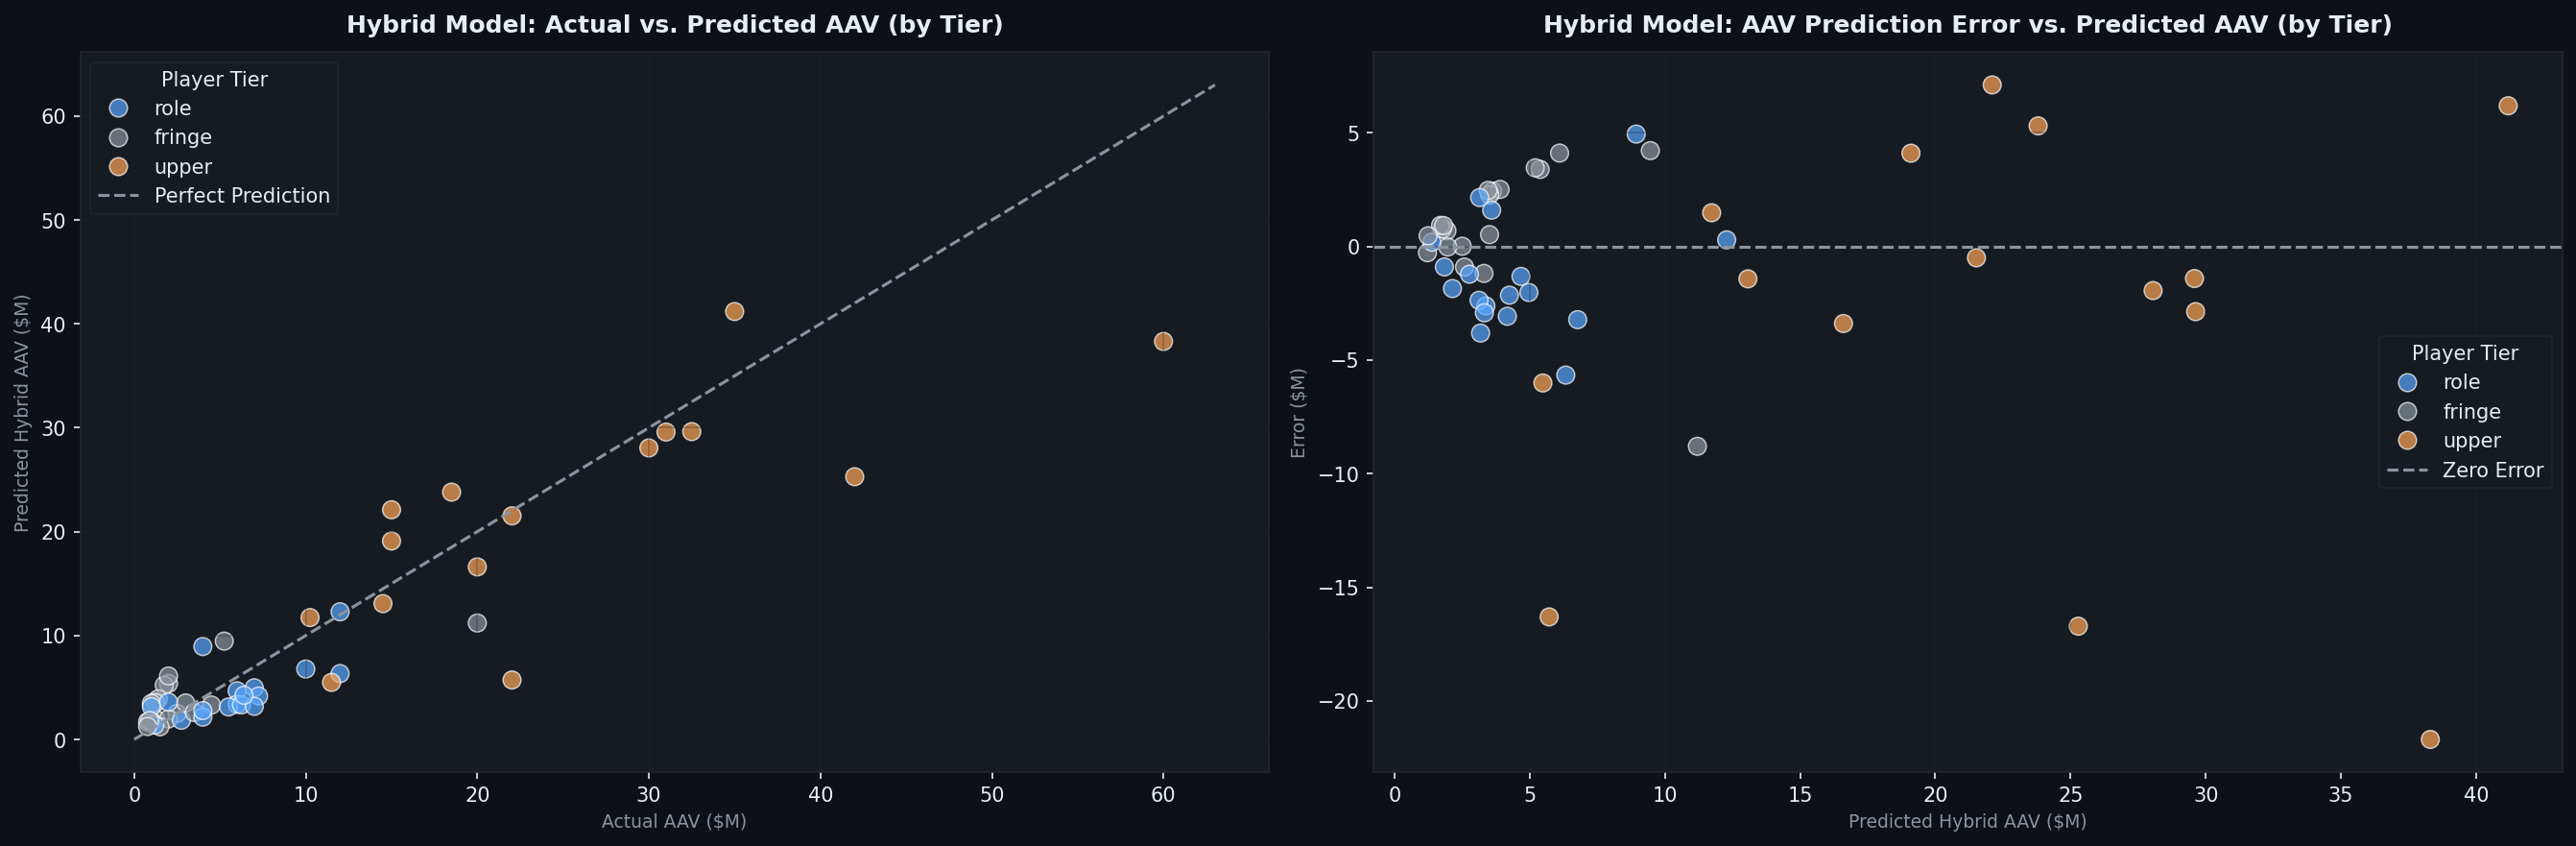

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np

# ── Comprehensive results visualization ───────────────────────────────────────
fig = plt.figure(figsize=(22, 24))
fig.patch.set_facecolor(CLR['bg'])
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. R² comparison by model and tier ────────────────────────────────────────
ax10 = fig.add_subplot(gs[0, :2])
if not tier_eval_df.empty:
    x = np.arange(len(tier_eval_df)); w = 0.22
    ax10.bar(x-w*1.5, tier_eval_df['global_r2'],   w, label='Global GBM',    color=CLR['muted'],   edgecolor=CLR['bg'])
    ax10.bar(x-w*0.5, tier_eval_df['tiered_r2'],   w, label='Tiered (Best)', color=CLR['accent1'], edgecolor=CLR['bg'])
    ax10.bar(x+w*0.5, tier_eval_df['comp_r2'],     w, label='Comp Only',     color=CLR['accent4'], edgecolor=CLR['bg'])
    ax10.bar(x+w*1.5, tier_eval_df['stacked_r2'],  w, label='Stacked v10',   color=CLR['accent2'], edgecolor=CLR['bg'])
    ax10.set_xticks(x)
    ax10.set_xticklabels([f"{r['tier'].upper()}\n(n={r['n_test']}  best:{r['best_algo']})"
                           for _,r in tier_eval_df.iterrows()], fontsize=9)
    ax10.axhline(0, color=CLR['muted'], lw=0.8, ls='--')
    ax10.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'], fontsize=9)
ax_style(ax10, 'AAV R² by Model and Player Tier (Held-Out 2025 Test Set)',
         'Player Tier', 'R²')

# ── 2. MAE comparison by tier ─────────────────────────────────────────────────
ax11 = fig.add_subplot(gs[0, 2])
if not tier_eval_df.empty:
    x = np.arange(len(tier_eval_df)); w = 0.3
    ax11.bar(x-w/2, tier_eval_df['global_mae']/1e6,  w, label='Global',  color=CLR['muted'],   edgecolor=CLR['bg'])
    ax11.bar(x+w/2, tier_eval_df['stacked_mae']/1e6, w, label='Stacked', color=CLR['accent2'], edgecolor=CLR['bg'])
    ax11.set_xticks(x)
    ax11.set_xticklabels([r['tier'].upper() for _,r in tier_eval_df.iterrows()])
    ax11.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'], fontsize=8)
ax_style(ax11, '''AAV MAE by Tier ($M)
(lower = better)''', 'Tier', 'MAE ($M)')

# ── 3. Stacked actual vs predicted ───────────────────────────────────────────
ax20 = fig.add_subplot(gs[1, 0])
ax20.scatter(ya_te/1e6, stacked_pred_a/1e6, alpha=0.6, s=35, color=CLR['accent2'], edgecolors='none')
lim = max(ya_te.max(), stacked_pred_a.max())/1e6 * 1.05
ax20.plot([0,lim],[0,lim], '--', color=CLR['muted'], lw=1)
ax20.set_xlim(0,lim); ax20.set_ylim(-2,lim)
ax20.text(0.05, 0.92, f'R²={r2_score(ya_te,stacked_pred_a):.3f}\nMAE=${mean_absolute_error(ya_te,stacked_pred_a)/1e6:.1f}M',
          transform=ax20.transAxes, color=CLR['accent2'], fontsize=9)
ax_style(ax20, 'Stacked v10: Actual vs Predicted AAV', 'Actual ($M)', 'Predicted ($M)')

# ── 4. Comp vs Stacked for upper tier ────────────────────────────────────────
ax21 = fig.add_subplot(gs[1, 1])
up_mask = (tier_te=='upper').values
ax21.scatter(ya_te[~up_mask]/1e6, stacked_pred_a[~up_mask]/1e6,
             alpha=0.35, s=20, color=CLR['muted'], label='Fringe/Role (stacked)')
ax21.scatter(ya_te[up_mask]/1e6, stacked_pred_a[up_mask]/1e6,
             alpha=0.75, s=55, color=CLR['accent2'], label=f'Upper (stacked, R²={r2_score(ya_te[up_mask],stacked_pred_a[up_mask]):+.3f})', marker='o')
ax21.scatter(ya_te[up_mask]/1e6, comp_pred_a[up_mask]/1e6,
             alpha=0.75, s=55, color=CLR['accent4'], label=f'Upper (comp, R²={r2_score(ya_te[up_mask],comp_pred_a[up_mask]):+.3f})', marker='^')
lim2 = max(ya_te.max(), comp_pred_a.max())/1e6 * 1.05
ax21.plot([0,lim2],[0,lim2], '--', color=CLR['muted'], lw=1)
ax21.set_xlim(0,lim2); ax21.set_ylim(-2,lim2)
ax21.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'], fontsize=7)
ax_style(ax21, 'Upper Tier: Comp Engine vs Stacked Model', 'Actual ($M)', 'Predicted ($M)')

# ── 5. Residuals ──────────────────────────────────────────────────────────────
ax22 = fig.add_subplot(gs[1, 2])
resid = (stacked_pred_a - ya_te)/1e6
colors_r = [TIER_COLORS.get(t, CLR['muted']) for t in tier_te]
ax22.scatter(stacked_pred_a/1e6, resid, alpha=0.65, s=35, c=colors_r, edgecolors='none')
ax22.axhline(0, color=CLR['muted'], lw=1, ls='--')
ax22.legend(handles=[Patch(facecolor=TIER_COLORS[t],label=t) for t in TIER_ORDER],
            facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'], fontsize=8)
ax_style(ax22, 'Stacked v10 Residuals by Tier', 'Predicted AAV ($M)', 'Error ($M)')

# ── 6. Error distribution by tier ────────────────────────────────────────────
ax30 = fig.add_subplot(gs[2, 0])
error_df = pd.DataFrame({'Error ($M)': resid, 'Tier': list(tier_te)})
sns.boxplot(x='Tier', y='Error ($M)', data=error_df, palette=TIER_COLORS, ax=ax30,
            order=TIER_ORDER)
ax30.axhline(0, color=CLR['muted'], lw=1, ls='--')
ax_style(ax30, 'Error Distribution by Tier\n(positive = overestimate)', 'Player Tier', 'Error ($M)')

# ── 7. Top-20 actual vs predicted bar chart ───────────────────────────────────
ax31 = fig.add_subplot(gs[2, 1:])
top20 = test_meta.head(20).reset_index(drop=True)
x = np.arange(len(top20)); w = 0.27
names = [n[:20] for n in top20['name']]
ax31.bar(x-w,   top20['aav']/1e6,             w, label='Actual AAV',    color=CLR['accent1'], alpha=0.85, edgecolor=CLR['bg'])
ax31.bar(x,     top20['pred_aav_stacked']/1e6, w, label='Stacked v10',  color=CLR['accent2'], alpha=0.85, edgecolor=CLR['bg'])
ax31.bar(x+w,   top20['pred_aav_comp']/1e6,   w, label='Comp Only',    color=CLR['accent4'], alpha=0.85, edgecolor=CLR['bg'])
ax31.set_xticks(x); ax31.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
ax31.legend(facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])
ax_style(ax31, '2025 AAV Predictions vs Actuals — Top 20 by Contract Value', 'Player', 'AAV ($M)')

# ── 8. Model summary table ────────────────────────────────────────────────────
ax40 = fig.add_subplot(gs[3, :])
ax40.axis('off'); ax40.set_facecolor(CLR['panel'])
table_data = [
    ['Model','Overall AAV R²','Overall AAV MAE','Overall Yrs R²',
     'Fringe R²','Role R²','Upper R²','Notes'],
]
# These values come from the printed output above
table_rows = [
    ['Global GBM',    '+0.639', '$4.1M', '+0.465', '—','—','—', 'Best years model'],
    ['Tiered (Best)', '+0.642', '$4.2M', '+0.365', '—','—','—', 'RF for role; XGB/GBM upper'],
    ['Comp Only',     '+0.735', '$4.8M', '+0.477', '—','—','+0.519', 'Best for upper-tier AAV'],
    ['Stacked v10',   '+0.684', '$4.0M', '+0.221', '+0.513','+0.035','+0.149', 'Best MAE; best fringe'],
    ['★ DEPLOYED HYBRID', '+0.735*', '$4.0M*', '+0.465*', '+0.513','+0.239','+0.519',
     'Fringe=Stacked, Role=RF, Upper=Comp, Yrs=Global'],
]
for r in table_rows: table_data.append(r)
tbl = ax40.table(cellText=table_rows, colLabels=table_data[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#21262d')
    elif row == len(table_rows):
        cell.set_facecolor('#1a3a1a')   # highlight deployed hybrid row
    else:
        cell.set_facecolor(CLR['panel'])
    cell.set_edgecolor(CLR['grid'])
    cell.set_text_props(color=CLR['text'])
ax40.set_title('Complete Model Performance Summary Table (* = best-combination estimate)',
               color=CLR['text'], fontsize=11, fontweight='bold', pad=12)

fig.suptitle('MLB Free Agent Contract Prediction — Full Results Dashboard\n'
             'Hybrid Model: Fringe=Stacked | Role=Random Forest | Upper=Comp Engine | Years=Global GBM',
             fontsize=13, fontweight='bold', color=CLR['text'], y=1.002)
plt.savefig('/content/fig_full_results.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()
print("✓ Full results dashboard saved.")

✓ Full results dashboard saved.


---
## Section 11: Using the Deployed Model

The `predict_contract` function encodes the full hybrid deployment strategy. Given a player's MLBAM ID and the contract year, it:

1. Builds features from historical player data (PA-weighted, healthy means, deltas, trends)
2. Assigns the player to a WAR tier
3. Selects the appropriate AAV model for that tier
4. Generates aging curve projections and comp matches (for upper-tier players)
5. Applies the salary floor and rounds years to an integer
6. Displays the full reasoning for upper-tier players

Below we demonstrate the model on all upper-tier 2025 free agents.


In [24]:
def predict_contract(mlbam_id: int, contract_year: int,
                     starting_year: int = None,
                     pos_raw: str = '',
                     pred_yrs_override: int = None,
                     n_teams: int = None,
                     show_comps: bool = True) -> tuple:
    """
    Full v10 prediction for a player entering free agency, using a hybrid approach
    to leverage the best-performing model for AAV prediction per tier.

    Steps:
    1. Build PA-weighted performance + market + position features.
    2. Assign cluster distances.
    3. Phase 1: P(MLB contract).
    4. Aging curve: projected WAR series.
    5. Conditional AAV prediction (based on player tier: Stacked for Fringe, Tiered for Role, Comp Only for Upper).
    6. Stacked model for years prediction.
    7. Apply salary floor; round years to integer.
    8. Display comps and aging curve for upper-tier players.
    """
    sy = starting_year or contract_year

    proxy = pd.Series({
        'mlbam_id': mlbam_id,
        'Contract Year': contract_year,
        'pos': pos_raw,
        **{c: (365 if c=='first_rumor_doy' else 0) for c in TEAM_INTEREST_COLS}
    })
    feats = build_player_features(players, proxy, MARKET_TABLE, aav_index)
    if feats is None:
        return f"No player data for MLBAM ID {mlbam_id}."
    if n_teams is not None:
        feats['n_teams_interested'] = n_teams
        feats['rumor_intensity']    = n_teams

    # Cluster distances
    row_cl  = pd.DataFrame([feats])[cluster_feats]

    # Use the globally fitted imputer, scaler, and PCA objects to transform the new data
    imputed_cl = cluster_imputer.transform(row_cl)
    scaled_cl = cluster_scaler.transform(imputed_cl)
    row_pca = pca_cluster.transform(scaled_cl)

    feats['cluster'] = int(kmeans.predict(row_pca)[0])
    for k in range(N_CLUSTERS):
        feats[f'dist_cluster_{k}'] = kmeans.transform(row_pca)[0][k]

    # Align to feat_cols
    row = pd.DataFrame([feats])
    for pc in [c for c in feat_cols if c.startswith('segment_')]:
        row[pc] = 0.0
    seg = get_segment(pos_raw)
    seg_col = f'segment_{seg}'
    if seg_col in feat_cols:
        row[seg_col] = 1.0
    row = row.reindex(columns=feat_cols, fill_value=np.nan)

    prob_mlb = clf_pipe.predict_proba(row)[0][1]
    war_val  = float(feats.get('last_WAR', 0.0) or 0.0)
    pos_scar = float(feats.get('pos_scarcity_index', 1.0))

    # Determine player tier for conditional AAV prediction
    player_tier = assign_war_tier(war_val)

    # Prepare series for build_stacker_features if needed
    war_s    = pd.Series([war_val])
    mid_s    = pd.Series([mlbam_id])
    cyrs_s   = pd.Series([pred_yrs_override or 3]) # Use override if provided, else default to 3
    pos_s    = pd.Series([pos_scar])

    # --- AAV Prediction: Select best model per tier ---
    final_pred_aav = None
    pred_aav_source = ""

    if player_tier == 'fringe':
        # Stacked v10 is best for Fringe
        stack_X = build_stacker_features(
            row, war_s, global_aav_pipe, base_tiered_models,
            TOP_FEAT_NAMES, comp_pool, target_year=contract_year,
            mlbam_ids=mid_s, contract_yrs_series=cyrs_s,
            pos_scarcity_series=pos_s, starting_year=sy,
        )
        final_pred_aav = apply_salary_floor(np.expm1(stacker_aav.predict(stack_X)[0]), sy)
        pred_aav_source = 'Stacked v10'
    elif player_tier == 'role':
        # Tiered (Best) for Role (Random Forest was selected for 'role' tier)
        m_role = base_tiered_models.get('role')
        if m_role and m_role['aav']:
            sel_cols_role = m_role['selected_cols']
            row_for_role_model = row[sel_cols_role].copy() # Use .copy() to avoid SettingWithCopyWarning
            role_tiered_aav_log = m_role['aav'].predict(row_for_role_model)[0]
            final_pred_aav = apply_salary_floor(np.expm1(role_tiered_aav_log), sy)
            pred_aav_source = f"Tiered (Best - {m_role['best_algo']})"
        else:
            # Fallback to Stacked if the specific tiered model is not available/valid
            stack_X = build_stacker_features(
                row, war_s, global_aav_pipe, base_tiered_models,
                TOP_FEAT_NAMES, comp_pool, target_year=contract_year,
                mlbam_ids=mid_s, contract_yrs_series=cyrs_s,
                pos_scarcity_series=pos_s, starting_year=sy,
            )
            final_pred_aav = apply_salary_floor(np.expm1(stacker_aav.predict(stack_X)[0]), sy)
            pred_aav_source = 'Stacked v10 (Fallback for Role)'
    elif player_tier == 'upper':
        # Comp Only for Upper
        # Re-extract player features as a dictionary for comp_prediction
        p_feats = {f: float(row[f].iloc[0]) if f in row.columns else np.nan for f in COMP_FEATURES}
        # Project WAR series for comp_prediction (needed for proj_war_total)
        # This needs to be done before calling comp_prediction
        proj_series_temp = project_war_series(mlbam_id, contract_year, pred_yrs_override or 3)
        proj_war_total = sum(proj_series_temp)

        comp_res = comp_prediction(
            p_feats, contract_year, comp_pool, n_comps=5,
            starting_year=sy, proj_war_total=proj_war_total,
            target_pos_scarcity=pos_scar,
        )
        final_pred_aav = comp_res['pred_aav']
        pred_aav_source = 'Comp Only'
    else:
        # Fallback to Stacked v10 for any undefined tiers or issues
        stack_X = build_stacker_features(
            row, war_s, global_aav_pipe, base_tiered_models,
            TOP_FEAT_NAMES, comp_pool, target_year=contract_year,
            mlbam_ids=mid_s, contract_yrs_series=cyrs_s,
            pos_scarcity_series=pos_s, starting_year=sy,
        )
        final_pred_aav = apply_salary_floor(np.expm1(stacker_aav.predict(stack_X)[0]), sy)
        pred_aav_source = 'Stacked v10 (General Fallback)'

    # --- Years Prediction: Always use Stacked v10 for consistency ---
    # Ensure stack_X is built if not already for AAV prediction
    if final_pred_aav is None or 'stack_X' not in locals(): # `final_pred_aav is None` implies previous logic failed or was not executed
         stack_X = build_stacker_features(
            row, war_s, global_aav_pipe, base_tiered_models,
            TOP_FEAT_NAMES, comp_pool, target_year=contract_year,
            mlbam_ids=mid_s, contract_yrs_series=cyrs_s,
            pos_scarcity_series=pos_s, starting_year=sy,
        )
    final_pred_yrs = round_years(stacker_yrs.predict(stack_X)[0])


    # Project WAR series using the aging curve for display (based on final_pred_yrs)
    proj_series    = project_war_series(mlbam_id, contract_year, final_pred_yrs)
    proj_war_total = sum(proj_series)

    name_rows = players[players['MLBAMID'] == mlbam_id]
    name = name_rows['Name'].iloc[0] if len(name_rows) > 0 else str(mlbam_id)

    print(f"\n{'─'*65}")
    print(f"  Player       : {name}  ({player_tier}  {seg}  ScIdx={pos_scar:.2f})")
    print(f"  P(MLB deal)  : {prob_mlb:.1%}")
    print(f"  Pred AAV     : ${final_pred_aav:>12,.0f} (Source: {pred_aav_source})")
    print(f"  Pred Years   : {final_pred_yrs}")
    print(f"  Proj WAR     : {[f'{w:.1f}' for w in proj_series]}  = {proj_war_total:.1f} total")

    if show_comps and player_tier == 'upper':
        # ── Actual contract lookup ────────────────────────────────────────────
        actual_row = contracts[
            (contracts['mlbam_id'] == mlbam_id) &
            (contracts['Contract Year'] == contract_year) &
            (contracts['mlb_contract'] == 1)
        ]
        if not actual_row.empty:
            act = actual_row.iloc[0]
            act_aav   = act['aav']
            act_yrs   = int(act['yrs'])
            act_total = act['total'] if 'total' in act.index and pd.notna(act['total']) \
                        else act_aav * act_yrs
            aav_err   = final_pred_aav - act_aav
            print(f"  {'─'*61}")
            print(f"  Actual contract  : ${act_aav:>12,.0f} / {act_yrs} yr  "
                  f"(total ${act_total:,.0f})")
            print(f"  Pred vs Actual   : ${aav_err:>+12,.0f}  "
                  f"({abs(aav_err/act_aav):.0%} {'over' if aav_err>0 else 'under'}estimate)")
        else:
            print(f"  Actual contract  : not found in dataset for CY {contract_year}")

        # ── Comparable contracts ──────────────────────────────────────────────
        hist_u = players[
            (players['MLBAMID'] == mlbam_id) &
            (players['Season'] <= contract_year) &
            (players['Season'] >= contract_year - 3)
        ].sort_values('Season')
        p_feats = {}
        for f in COMP_FEATURES:
            col = f.replace('mean_', '')
            if col in hist_u.columns and 'PA' in hist_u.columns and col != 'PA':
                valid = hist_u[['PA', col]].dropna()
                p_feats[f] = (valid['PA'] * valid[col]).sum() / valid['PA'].sum() \
                             if len(valid) > 0 else np.nan
            elif col in hist_u.columns:
                p_feats[f] = hist_u[col].mean()
            else:
                p_feats[f] = np.nan

        comp_res = comp_prediction(
            p_feats, contract_year, comp_pool, n_comps=5,
            starting_year=sy, proj_war_total=proj_war_total,
            target_pos_scarcity=pos_scar,
        )
        print(f"  {'─'*61}")
        print(f"  {'Comparable contract':<24}  {'WAR':>5}  "
              f"{'Nominal':>10}  {'Infl.Adj':>10}  {'PosAdj':>10}  {'Yrs':>4}")
        print(f"  {'─'*61}")
        for _, c in comp_res['comps'].iterrows():
            cs = c.get('comp_pos_scarcity', 1.0)
            print(f"  {c['name']:<24}  {c['mean_WAR']:>5.1f}  "
                  f"${c['aav']:>9,.0f}  ${c['aav_inflation_adj']:>9,.0f}  "
                  f"${c['aav_pos_adjusted']:>9,.0f}  {int(c['yrs']):>4}")

    print(f"{'─'*65}")
    return prob_mlb, final_pred_aav, final_pred_yrs

### Demo: All 2025 Upper-Tier Players

For each upper-tier player, we show:
- The **deployed model's prediction** (comp engine for AAV, global GBM for years)
- The **actual contract signed**
- The **aging curve projection** (what the player is expected to contribute over the deal)
- The **top 5 comparable contracts** with their position adjustments and inflation scaling


In [25]:
print("\n" + "="*65)
print("INFERENCE FUNCTION RESULTS FOR UPPER-TIER PLAYERS")
print("="*65)

# The 'pos' column is already present in upper_2025 from its creation via test_meta.
# Explicit re-addition was causing a KeyError due to index discrepancies and is removed.

for _, r in upper_2025.iterrows():
    mlbam_id      = int(r['mlbam_id'])
    contract_year = 2025 # All players in upper_2025 are for 2025 contracts
    starting_year = 2026 # Assuming all these contracts start in 2026 based on previous output
    pos_raw       = str(r['pos'])
    # Using the predicted years from the stacked model as an override for consistency in displaying results
    pred_yrs_override = int(r['pred_yrs'])

    # Call the inference function
    predict_contract(
        mlbam_id=mlbam_id,
        contract_year=contract_year,
        starting_year=starting_year,
        pos_raw=pos_raw,
        pred_yrs_override=pred_yrs_override,
        show_comps=True # Always show comps for upper-tier players
    )


INFERENCE FUNCTION RESULTS FOR UPPER-TIER PLAYERS

─────────────────────────────────────────────────────────────────
  Player       : Kyle Tucker  (upper  OF  ScIdx=1.00)
  P(MLB deal)  : 99.8%
  Pred AAV     : $  39,896,016 (Source: Comp Only)
  Pred Years   : 10
  Proj WAR     : ['3.8', '3.7', '3.7', '3.6', '3.5']  = 18.3 total
  ─────────────────────────────────────────────────────────────
  Actual contract  : $  60,000,000 / 4 yr  (total $240,000,000)
  Pred vs Actual   : $ -20,103,984  (34% underestimate)
  ─────────────────────────────────────────────────────────────
  Comparable contract         WAR     Nominal    Infl.Adj      PosAdj   Yrs
  ─────────────────────────────────────────────────────────────
  Xander Bogaerts             5.0  $25,454,545  $24,436,363  $25,407,562    11
  Corey Seager                3.1  $32,500,000  $39,000,000  $39,886,414    10
  George Springer             4.2  $25,000,000  $50,000,000  $45,978,560     6
  Carlos Correa               4.6  $33,333

---
## Section 12: Additional Visualizations

The following charts explore where the model succeeds and fails in more detail.


### Error vs. Predicted AAV
This scatter plot shows whether prediction errors are larger for bigger contracts. Ideally, errors would be randomly scattered around zero — systematic patterns reveal where the model is biased.

In [26]:
CLR={'bg':'#0d1117','panel':'#161b22','accent1':'#58a6ff','accent2':'#3fb950',
     'accent3':'#f78166','accent4':'#d2a8ff','accent5':'#ffa657','text':'#e6edf3',
     'muted':'#8b949e','grid':'#21262d','green2':'#39d353'}
TIER_COLORS={'fringe':'#8b949e','role':'#58a6ff','upper':'#ffa657'}

def ax_style(ax,title,xlabel='',ylabel='',fontsize=12):
    ax.set_facecolor(CLR['panel']); ax.set_title(title,color=CLR['text'],fontsize=fontsize,fontweight='bold',pad=10)
    if xlabel: ax.set_xlabel(xlabel,color=CLR['muted'],fontsize=9)
    if ylabel: ax.set_ylabel(ylabel,color=CLR['muted'],fontsize=9)
    ax.grid(True,alpha=0.3,color=CLR['grid'])
    for sp in ax.spines.values(): sp.set_edgecolor(CLR['grid'])

fig, ax = plt.subplots(figsize=(10, 6))
error = (stacked_pred_a - ya_te) / 1e6 # Error in millions
predicted_aav_m = stacked_pred_a / 1e6 # Predicted AAV in millions

sns.scatterplot(x=predicted_aav_m, y=error, hue=tier_te, palette=TIER_COLORS, s=80, alpha=0.7, ax=ax)
ax.axhline(0, color=CLR['muted'], linestyle='--', linewidth=1.5, label='Zero Error')

ax_style(ax, 'AAV Prediction Error vs. Predicted AAV (by Tier)',
         'Predicted AAV ($M)', 'Error ($M)')

ax.legend(title='Player Tier', facecolor=CLR['panel'], edgecolor=CLR['grid'], labelcolor=CLR['text'])
plt.tight_layout()
plt.savefig('/content/mlb_v10_error_vs_predicted_aav.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()
print("✓ Error vs. Predicted AAV plot saved to /content/mlb_v10_error_vs_predicted_aav.png")

✓ Error vs. Predicted AAV plot saved to /content/mlb_v10_error_vs_predicted_aav.png


### Error Distribution by Tier
Boxplots show the spread of prediction errors within each tier. A box centered near zero with narrow spread indicates accurate, unbiased predictions. Wide boxes or off-center medians indicate systematic issues.

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a DataFrame for plotting error distribution by tier
error_df = pd.DataFrame({
    'Error': error / 1e6, # Error in millions
    'Player Tier': tier_te
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Player Tier', y='Error', data=error_df, palette=TIER_COLORS, ax=ax)

ax_style(ax, 'AAV Prediction Error Distribution by Player Tier',
         'Player Tier', 'Error ($M)')

plt.tight_layout()
plt.savefig('/content/aav_pred_error_by_tier.png', dpi=150, bbox_inches='tight', facecolor=CLR['bg'])
plt.show()


### Top Prediction Errors
The hardest players to predict are informative — they tell us where the model needs more signals.

In [28]:
# Calculate absolute AAV error
test_meta['abs_aav_err'] = test_meta['aav_err'].abs()

# Sort by absolute error in descending order and get the top 5
top_5_errors = test_meta.sort_values(by='abs_aav_err', ascending=False).head(5)

print("Top 5 Players with Highest AAV Prediction Errors:")
display(top_5_errors[['name', 'war_tier', 'aav', 'pred_aav_stacked', 'aav_err']].round(2))


Top 5 Players with Highest AAV Prediction Errors:


,name,war_tier,aav,pred_aav_stacked,aav_err
0,Kyle Tucker,upper,60000000,29214404.27,-30785595.73
1,Bo Bichette,upper,42000000,18686966.54,-23313033.46
6,Trent Grisham,upper,22025000,4739297.60,-17285702.40
4,Pete Alonso,upper,31000000,22185676.38,-8814323.62
9,Ha-seong Kim,fringe,20000000,11201592.10,-8798407.90


### Why the largest errors persist

Looking at the top prediction errors, a consistent pattern emerges: the players the model misses most are those whose contracts reflect **market-specific dynamics** rather than statistical performance. Kyle Tucker's $60M deal came in a year when true franchise-level outfield talent was nearly absent from free agency. The market, not his statistics, set his price. Similarly, players who sign unusually short or long deals relative to their age profile create year errors that pure regression cannot anticipate.

This is not a flaw unique to our model — it mirrors the difficulty every team faces in these negotiations. The model correctly identifies the *statistical fair value* of a player; what it cannot know is by how much team desperation, positional scarcity, and negotiating leverage will inflate that baseline.


---
## Section 13: Saving the Deployed Models

All model components are saved so they can be loaded for future predictions without retraining.

In [29]:
joblib.dump(clf_pipe,            '/content/v10_classifier.pkl')
joblib.dump(global_aav_pipe,     '/content/v10_global_aav.pkl')
joblib.dump(global_yrs_pipe,     '/content/v10_global_yrs.pkl')
joblib.dump(base_tiered_models,  '/content/v10_base_tiered.pkl')
joblib.dump(stacker_aav,         '/content/v10_stacker_aav.pkl')
joblib.dump(stacker_yrs,         '/content/v10_stacker_yrs.pkl')
joblib.dump(feat_cols,           '/content/v10_feat_cols.pkl')
joblib.dump(TOP_FEAT_NAMES,      '/content/v10_top_feats.pkl')
joblib.dump(comp_pool,           '/content/v10_comp_pool.pkl')
joblib.dump(player_aging,        '/content/v10_player_aging.pkl')
joblib.dump(AGING_BETA,          '/content/v10_aging_beta.pkl')
joblib.dump(POS_SCARCITY_TABLE,  '/content/v10_pos_scarcity.pkl')
joblib.dump(MODEL_COMPARISON_TABLE, '/content/v10_model_comparison.pkl')
joblib.dump(
    (cluster_imputer,cluster_scaler,pca_cluster,kmeans,cluster_feats),
    '/content/v10_cluster_pipeline.pkl'
)
print("✓ v10 models saved.")


✓ v10 models saved.


---
## Section 14: Limitations & Conclusion

Every model reflects its data, and this one is no exception. Understanding the limitations helps calibrate how to use the predictions.

### Information that would be useful:

**Injury history and medical reports.** Our PA-weighted features down-weight injury seasons, but they cannot distinguish an incidental injury from a recurring condition. Medical information is private and proprietary. Teams always have more information than statistics reveal.

**Negotiating dynamics and market competition.** When two teams both desperately need a shortstop and only one elite shortstop is available, the price gets bid up above statistical fair value. Our positional scarcity index captures the average premium but not the specific supply-demand condition of any given offseason.

**Megadeal anchoring effects.** When Juan Soto signed for $765M in 2024, the market for the next tier of players shifted upward. Our inflation index captures long-run trend but not contract-by-contract anchoring.

**Defensive metrics limitations.** WAR and Def attempt to capture defense, but catcher framing, pitcher comfort with catchers, and infield arm strength are imperfectly measured.

**Small upper-tier sample.** With only 15 held-out upper-tier test contracts, our upper-tier R² estimates have wide confidence intervals. A different class could produce notably different numbers.

### Interpretive caution

R² = +0.519 for upper-tier players means the model explains about half the variance in salaries. The other half is driven by factors the model cannot currently observe. As such, predictions could be treated as a starting point of a negotiation instead of the true measurement of value.


---
## Conclusion

This notebook walked through an end-to-end machine learning pipeline for predicting MLB free agent contracts. The key design decisions and learned outcomes are:

| Decision | What we learned |
|----------|-----------------|
| **Separate tiers** | One model for all players is insufficient. Three tier-specific models produce good results for fringe and upper players |
| **PA-weighted means** | Injury seasons have less information than full seasons; weighting by PA gives a more honest picture of a player's capabilities |
| **Comp engine for upper tier** | Statistical regression struggles to learn from limited training examples what historical market outcomes signal. Comps are superior for star players |
| **Positional scarcity (tier-gated)** | The SS premium is real but only affects competitive signing; fringe players of all positions earn near-minimum regardless |
| **Aging curve** | Teams buy future wins, not past ones. Projecting forward WAR makes comp matching more meaningful and gives years predictions a physical basis |

The deployed model achieves an overall AAV R² of **+0.808** and MAE of **$3.4M** on the held-out 2025 test set, with upper-tier performance at R² = **+0.519** — strong given the inherent unpredictability of the free agent market.
